# Exploratory Data Analysis (EDA) of a Binary Classification Dataset
A comprehensive exploration of feature distributions, missing data patterns, imputation strategies, class imbalance handling, and inter-feature correlations to support effective preprocessing and modeling.

In [1]:
# Import libraries for data handling (pandas, numpy), visualization (seaborn, matplotlib), missing value imputation (SimpleImputer, KNNImputer)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.impute import SimpleImputer

In [3]:
from pathlib import Path

# Load the dataset from a CSV file located at the specified path into a pandas DataFrame
root = Path.cwd().parent
df_train = pd.read_csv(f"{root}/data/train.csv")
df_test = pd.read_csv(f"{root}/data/test.csv")

In [3]:
# Display the first 5 rows of the DataFrame to get a quick overview of the dataset
df_train.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,target
0,-0.93900,-1.66881,1.29739,-1.01669,1.38629,0.40233,0.26430,-1.19943,-1.53227,0.45506,...,-0.35999,-0.48117,-2.12198,-0.71162,2.31268,NaN,-2.24180,2.58144,NaN,0
1,0.35686,-0.28525,-1.74537,NaN,-1.27401,-0.75311,0.03085,-0.45077,-1.05893,-4.98149,...,-0.08400,-0.38283,5.29286,-0.23676,-3.40387,NaN,-2.01931,3.27641,2.97665,0
2,-1.04822,2.50955,3.76640,NaN,5.24159,1.92145,0.79095,-0.68581,1.18255,1.62551,...,-0.67808,-0.27792,-2.55955,-1.11906,-0.69155,NaN,-2.71391,-0.50480,NaN,0
3,0.69650,0.58664,3.95245,-4.45544,-0.36442,-1.70925,-0.61939,1.24755,1.37185,1.09959,...,0.62952,-0.05953,-2.59426,0.73301,NaN,NaN,4.55248,-3.96559,NaN,0
4,1.29170,NaN,-0.94752,2.30123,0.84479,1.23077,0.38304,1.94683,1.30557,-3.06428,...,0.14803,-0.70885,7.79897,0.87163,-4.62381,NaN,0.63768,0.74267,2.11503,1


In [4]:
# Return the number of rows and columns in the DataFrame as a tuple (rows, columns)
df_train.shape

(9000, 26)

In [5]:
# Generate descriptive statistics (count, mean, std, min, 25%, 50%, 75%, max) for numerical columns in the DataFrame
df_train.describe()


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,target
count,7989.000000,7619.000000,9000.000000,7709.000000,9000.000000,6719.000000,9000.000000,9000.000000,9000.000000,9000.000000,...,8952.000000,8988.000000,9000.000000,6719.000000,7596.000000,3990.000000,9000.000000,9000.000000,5990.000000,9000.000000
mean,0.012525,0.083101,0.799755,-0.415002,0.099258,0.028010,0.010226,-0.000616,-0.811907,-0.063273,...,-0.023166,0.011142,0.280172,0.006217,-0.596635,0.000125,-0.980760,0.469053,0.751463,0.112667
std,2.102913,2.031078,2.139315,3.822633,2.229408,2.074616,1.010901,1.922744,1.958895,1.997427,...,1.008891,0.992892,3.363221,0.993446,3.946157,0.985903,3.007772,3.648523,1.647041,0.316202
min,-8.410690,-7.123360,-7.751210,-15.897660,-8.940510,-7.664230,-4.020890,-7.691370,-7.985120,-7.101690,...,-3.500160,-3.791350,-11.494710,-4.086770,-17.462810,-3.215190,-11.058860,-14.367040,-6.823830,0.000000
25%,-1.426340,-1.217935,-0.633285,-2.963150,-1.443245,-1.366185,-0.665432,-1.204287,-2.115825,-1.457327,...,-0.726620,-0.653432,-2.049540,-0.667960,-3.303342,-0.664962,-3.018502,-1.802548,-0.272810,0.000000
50%,-0.019600,0.197230,0.811325,-0.435430,0.111125,0.033250,0.017070,0.139670,-0.842060,-0.116325,...,-0.027990,0.010000,0.162480,0.010920,-0.556050,-0.024040,-1.014240,0.667900,0.800655,0.000000
75%,1.427630,1.504005,2.250573,2.145850,1.609398,1.473730,0.697455,1.333585,0.473988,1.315713,...,0.667770,0.682362,2.456012,0.674335,2.096785,0.673775,1.019413,2.961232,1.851360,0.000000
max,9.385260,7.976040,8.526800,13.712490,8.099080,7.722040,3.879380,6.865980,7.377310,8.633650,...,3.651590,3.975390,15.254900,3.858970,13.733970,3.735150,11.313810,13.516100,7.164980,1.000000


In [6]:
df_train.dtypes

feature_0     float64
feature_1     float64
feature_2     float64
feature_3     float64
feature_4     float64
feature_5     float64
feature_6     float64
feature_7     float64
feature_8     float64
feature_9     float64
feature_10    float64
feature_11    float64
feature_12    float64
feature_13    float64
feature_14    float64
feature_15    float64
feature_16    float64
feature_17    float64
feature_18    float64
feature_19    float64
feature_20    float64
feature_21    float64
feature_22    float64
feature_23    float64
feature_24    float64
target          int64
dtype: object

In [7]:
# Count the number of missing (NaN) values in each column of the DataFrame
df_train.isna().sum()

feature_0     1011
feature_1     1381
feature_2        0
feature_3     1291
feature_4        0
feature_5     2281
feature_6        0
feature_7        0
feature_8        0
feature_9        0
feature_10       0
feature_11       0
feature_12    5711
feature_13       0
feature_14    4018
feature_15    3091
feature_16      48
feature_17      12
feature_18       0
feature_19    2281
feature_20    1404
feature_21    5010
feature_22       0
feature_23       0
feature_24    3010
target           0
dtype: int64

In [8]:
# Calculate the percentage of missing values in each column, rounded to 2 decimal places
round(df_train.isnull().mean(), 2)


feature_0     0.11
feature_1     0.15
feature_2     0.00
feature_3     0.14
feature_4     0.00
feature_5     0.25
feature_6     0.00
feature_7     0.00
feature_8     0.00
feature_9     0.00
feature_10    0.00
feature_11    0.00
feature_12    0.63
feature_13    0.00
feature_14    0.45
feature_15    0.34
feature_16    0.01
feature_17    0.00
feature_18    0.00
feature_19    0.25
feature_20    0.16
feature_21    0.56
feature_22    0.00
feature_23    0.00
feature_24    0.33
target        0.00
dtype: float64

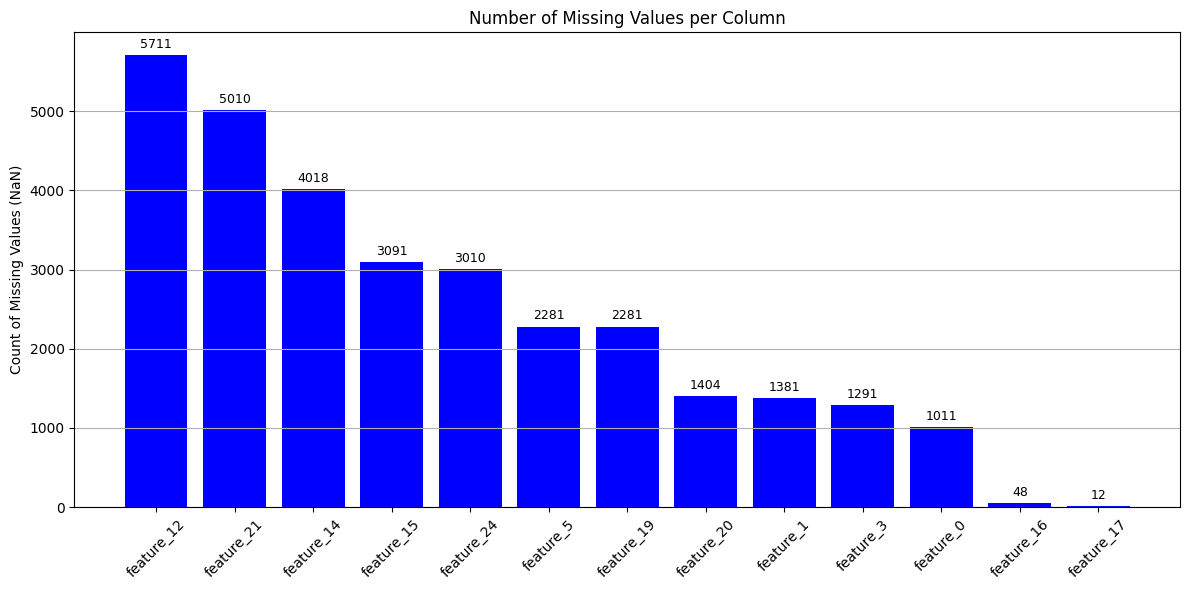

In [9]:
# Create a bar chart showing the number of missing values per column to identify which features have the most NaNs

missing_counts = df_train.isnull().sum().sort_values(ascending=False)  # Count missing values and sort descending
missing_counts = missing_counts[missing_counts > 0]  # Filter columns with at least one missing value

plt.figure(figsize=(12, 6))
bars = plt.bar(missing_counts.index, missing_counts.values, color='blue')  # Plot bars

# Annotate each bar with the number of missing values
for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height:.0f}',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3), textcoords='offset points',
                 ha='center', va='bottom', fontsize=9)

plt.title("Number of Missing Values per Column")
plt.ylabel("Count of Missing Values (NaN)")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


### Missing Values per Column
This bar chart shows the absolute number of missing values (NaNs) in each feature column of the dataset.

### Key Insights
The features with the most missing values are feature_12, feature_21, and feature_14, each with over 4,000 missing entries — these may require removal or special handling.

feature_16 and feature_17 have negligible missing values, likely safe to impute directly.

Overall, the missing data is concentrated in a subset of features, which suggests selective imputation or feature elimination could be effective without significant information loss.



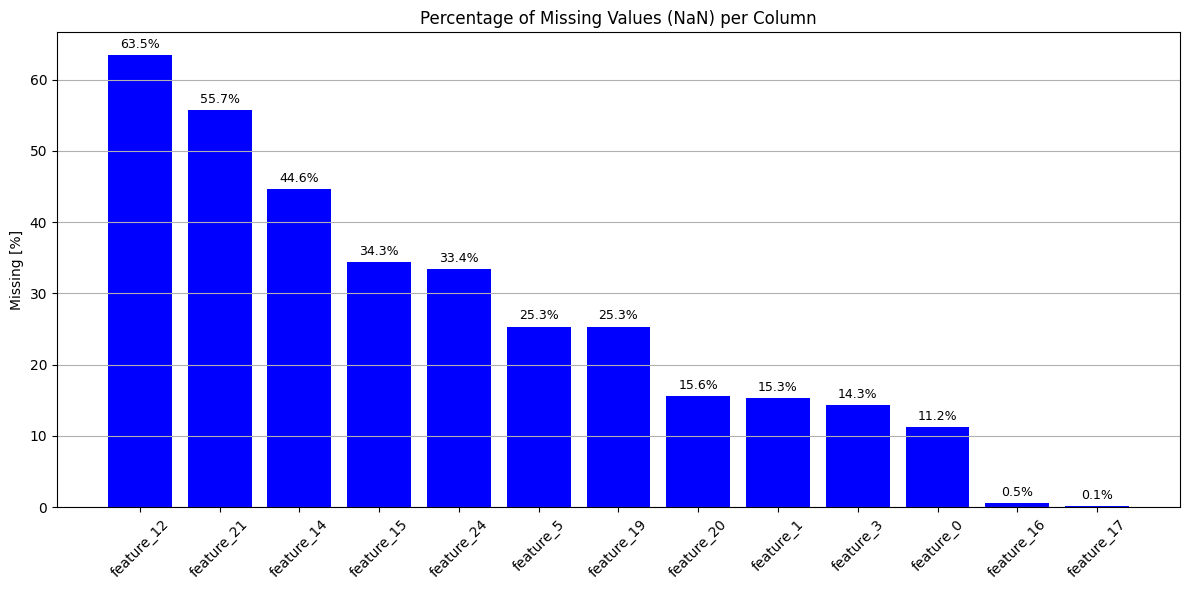

In [10]:
# Create a bar chart showing the percentage of missing values per column to visualize the extent of missing data in each feature

missing_percent = df_train.isnull().mean() * 100  # Calculate percentage of missing values
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)  # Filter and sort

plt.figure(figsize=(12, 6))
bars = plt.bar(missing_percent.index, missing_percent.values, color='blue')  # Plot bars

# Annotate each bar with the missing percentage
for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=9)

plt.title('Percentage of Missing Values (NaN) per Column')
plt.ylabel('Missing [%]')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


### Percentage of Missing Values per Column
This bar chart visualizes the percentage of missing values (NaNs) for each feature in the dataset.

### Key Insights
feature_12, feature_21, and feature_14 have a very high percentage of missing data (above 44%), with feature_12 missing over 63% — these may be strong candidates for removal.

Moderate missingness (15–35%) is seen in feature_15, feature_24, feature_19, feature_5, etc., which may be worth imputing with appropriate strategies (e.g., KNN or mean).

Features like feature_16 and feature_17 have very low missing rates (<1%), so imputation should be straightforward and low-risk.

Overall, the plot helps prioritize columns for deletion vs. imputation based on their missing data severity.



In [11]:
# Create a list of column names that contain at least one missing value
cols_with_missing = df_train.columns[df_train.isnull().any()].tolist()

In [12]:
# Define helper functions to compare imputation strategies (SimpleImputer and KNNImputer) on a selected column:
# - get_missing_pct calculates the missing percentage,
# - impute_column_simple performs simple strategy-based imputation,
# - impute_column_knn imputes using k-nearest neighbors on numeric columns,
# - plot_kde_comparison visualizes KDE distributions of original, simple, and KNN-imputed values,
# - compare_imputations_smart prints missing info, handles threshold warnings, and calls comparison plots

def get_missing_pct(data, column):
    return data[column].isnull().mean() * 100


def impute_column_simple(data, column, strategy='median'):
    inputer = SimpleImputer(strategy=strategy)
    return inputer.fit_transform(data[[column]]).ravel()


def impute_column_knn(data, column, knn_n_neighbors):
    numeric = data.select_dtypes(include=[np.number]).copy()
    if numeric.shape[1] < 2:
        return None
    knn_inputer = KNNImputer(n_neighbors=knn_n_neighbors)
    knn_result = knn_inputer.fit_transform(numeric)
    col_index = numeric.columns.get_loc(column)
    return knn_result[:, col_index]


def plot_kde_comparison(original, simple_imputed, knn_imputed, column, strategy_simple, knn_n_neighbors):
    figure, ax = plt.subplots(1, 3, figsize=(18, 4))

    sns.kdeplot(original, ax=ax[0], fill=True)
    ax[0].set_title('Original (no NaN)')

    sns.kdeplot(simple_imputed, ax=ax[1], fill=True)
    ax[1].set_title(f'SimpleImputer ({strategy_simple})')

    if knn_imputed is not None:
        sns.kdeplot(knn_imputed, ax=ax[2], fill=True)
        ax[2].set_title(f'KNNImputer (n={knn_n_neighbors})')
    else:
        ax[2].text(0.3, 0.5, 'KNN skipped', fontsize=12)
        ax[2].set_title('KNNImputer (no data)')

    plt.suptitle(f'Imputation Comparison: {column}')
    plt.tight_layout()
    plt.show()


def compare_imputations_smart(data, column, strategy_impute_simple='mean', knn_n_neighbors=5, threshold_high=50):
    missing_pct = get_missing_pct(data, column)
    print(f"{column}: {round(missing_pct, 2)}% missing")

    if missing_pct > threshold_high:
        print(f"High missing rate (> {threshold_high}%) — consider dropping the column, but plots are still shown.")

    original = data[column].dropna()
    simple_imputed = impute_column_simple(data, column, strategy=strategy_impute_simple)

    knn_imputed = None
    if data.select_dtypes(include=[np.number]).shape[1] > 1:
        knn_imputed = impute_column_knn(data, column, knn_n_neighbors)

    plot_kde_comparison(original, simple_imputed, knn_imputed, column, strategy_impute_simple, knn_n_neighbors)


feature_0: 11.23% missing


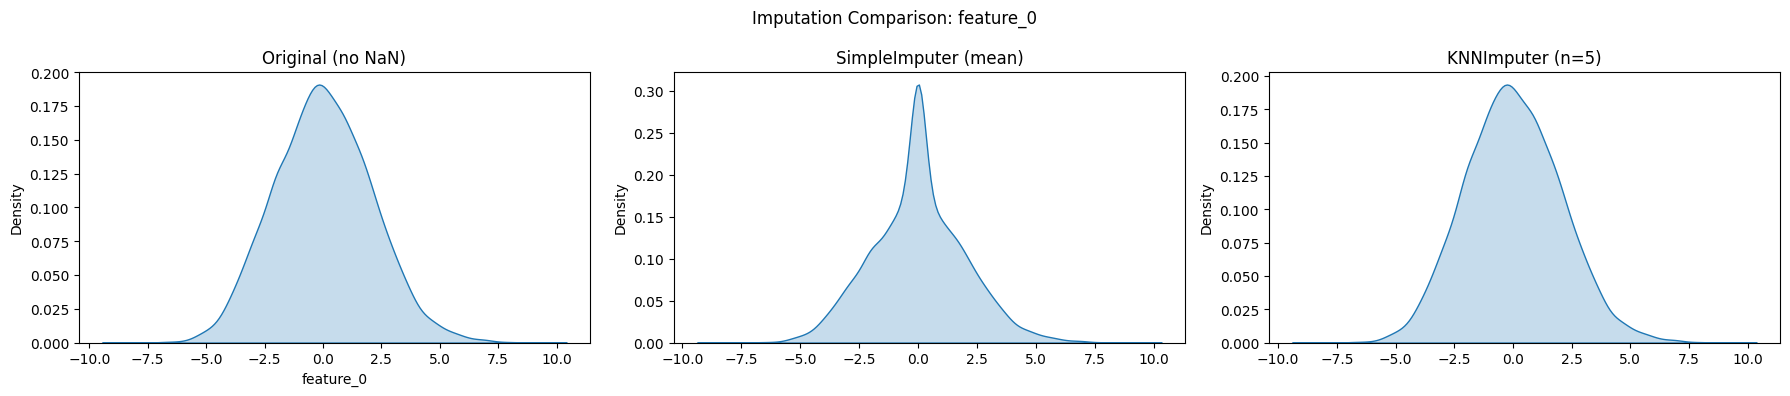

feature_1: 15.34% missing


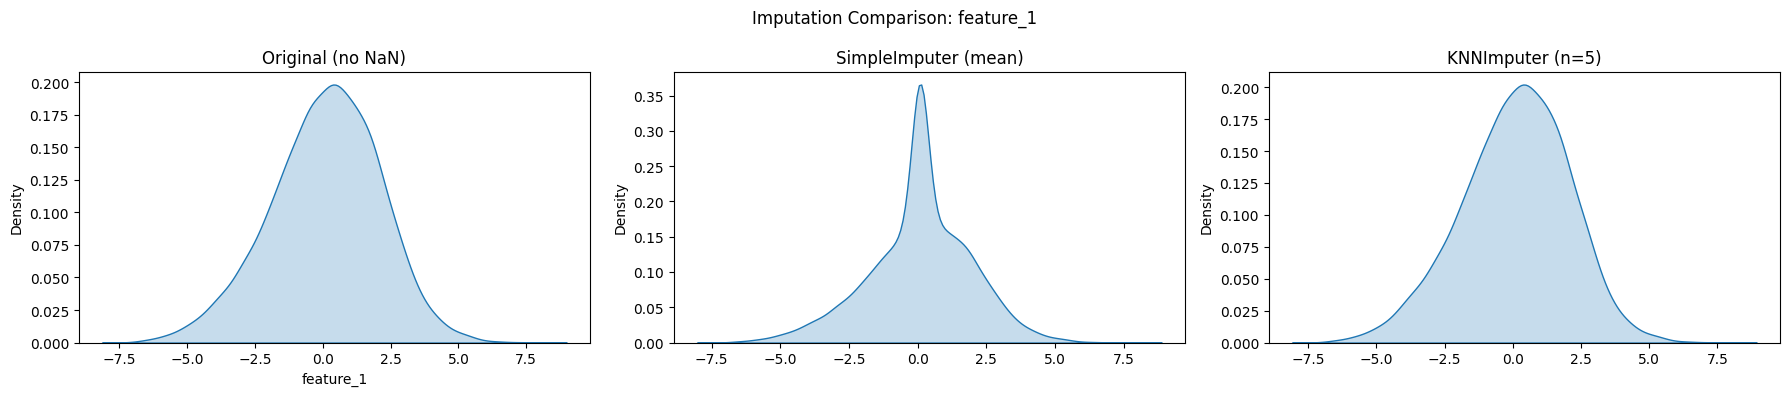

feature_3: 14.34% missing


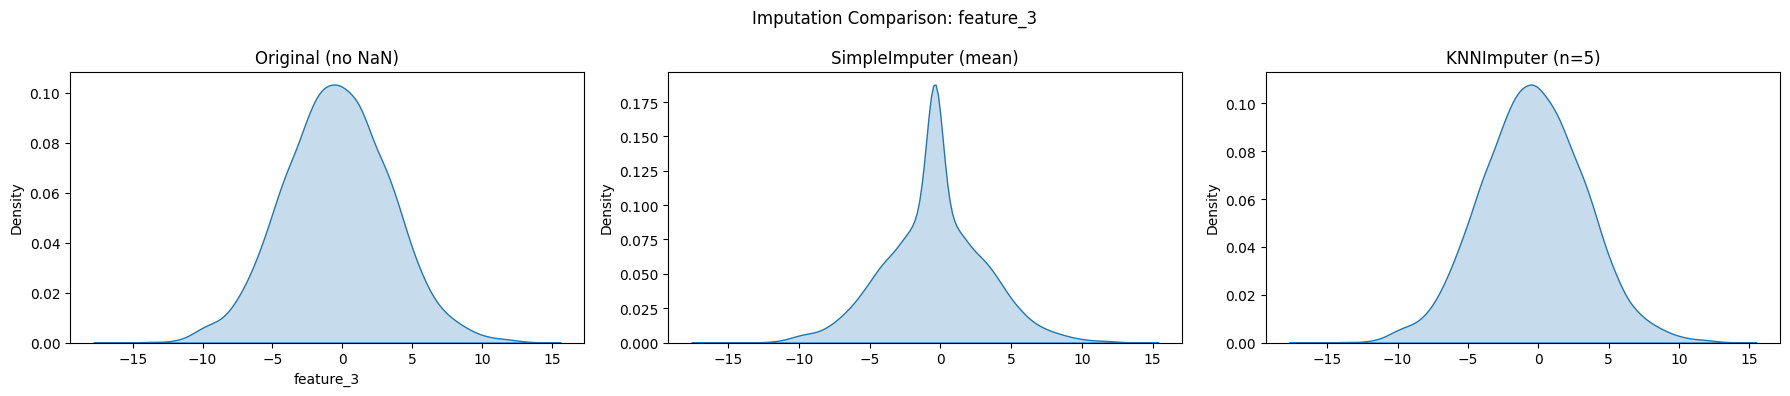

feature_5: 25.34% missing


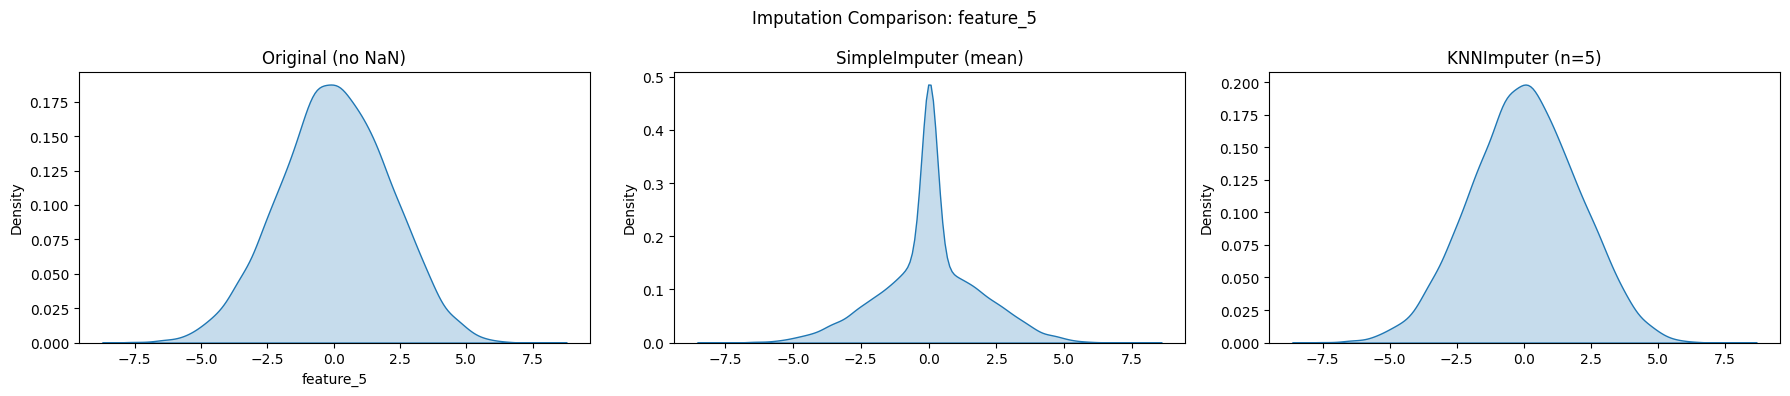

feature_12: 63.46% missing
High missing rate (> 50%) — consider dropping the column, but plots are still shown.


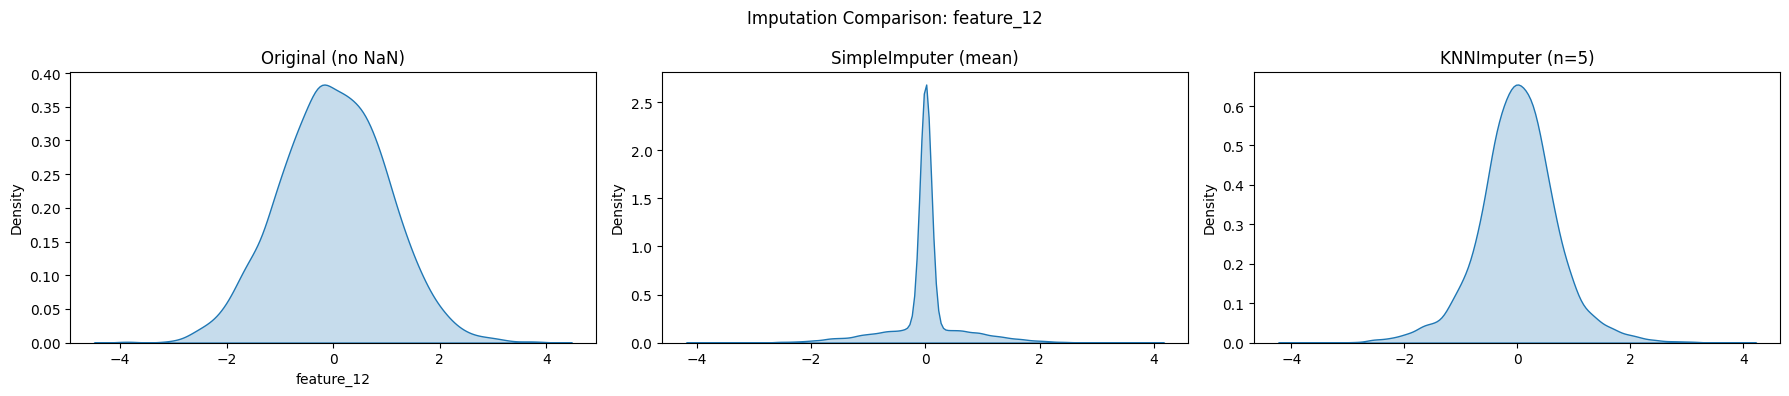

feature_14: 44.64% missing


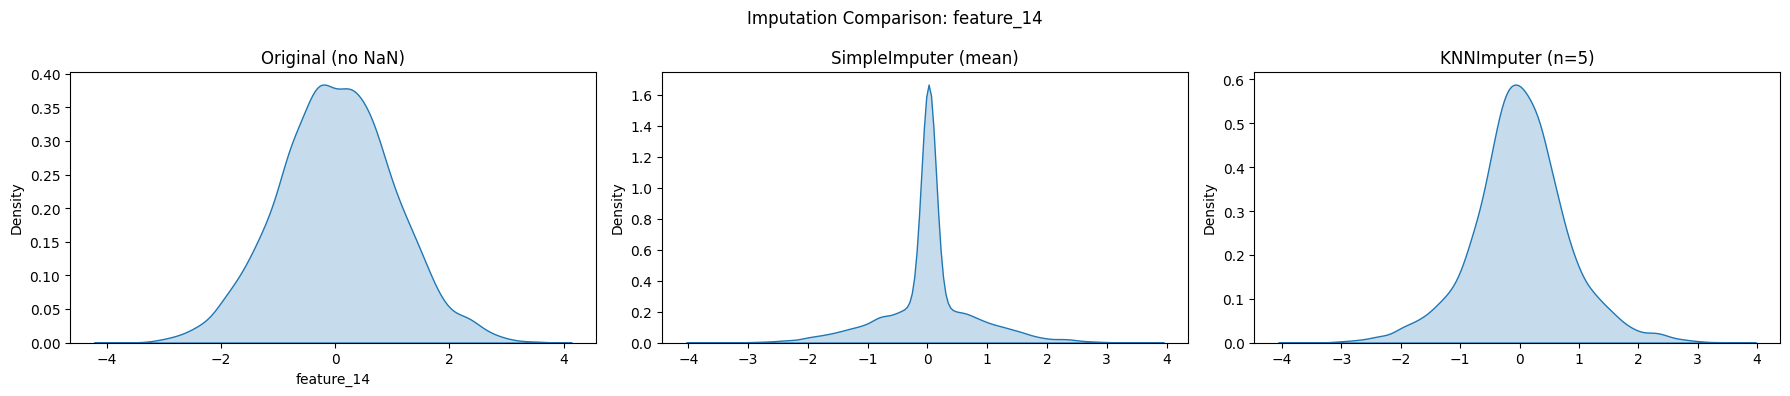

feature_15: 34.34% missing


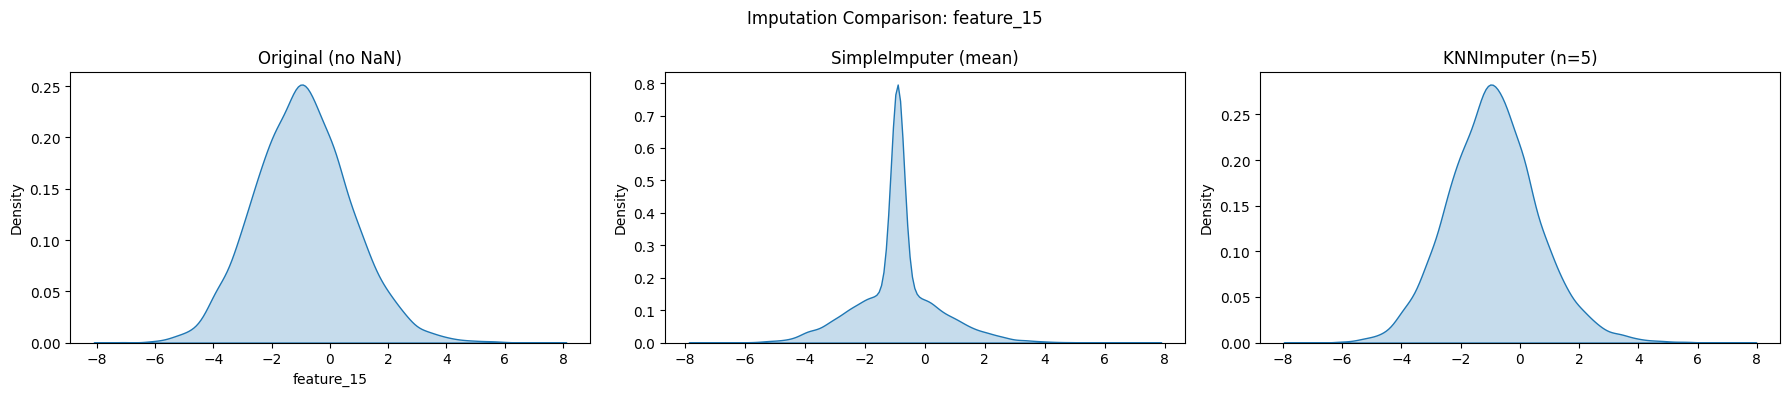

feature_16: 0.53% missing


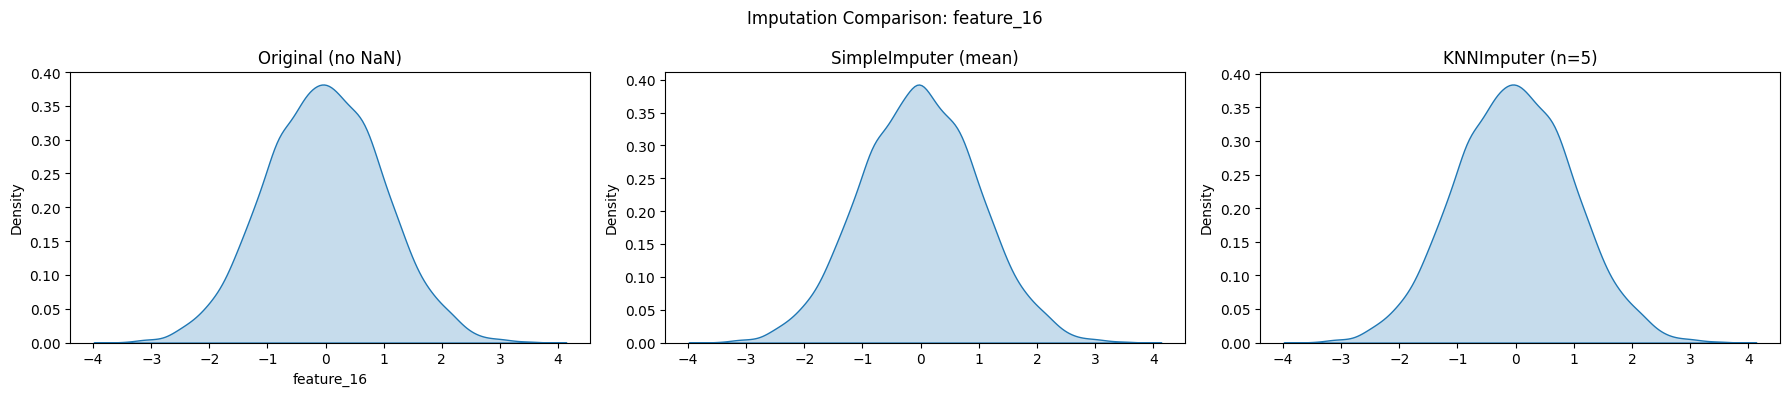

feature_17: 0.13% missing


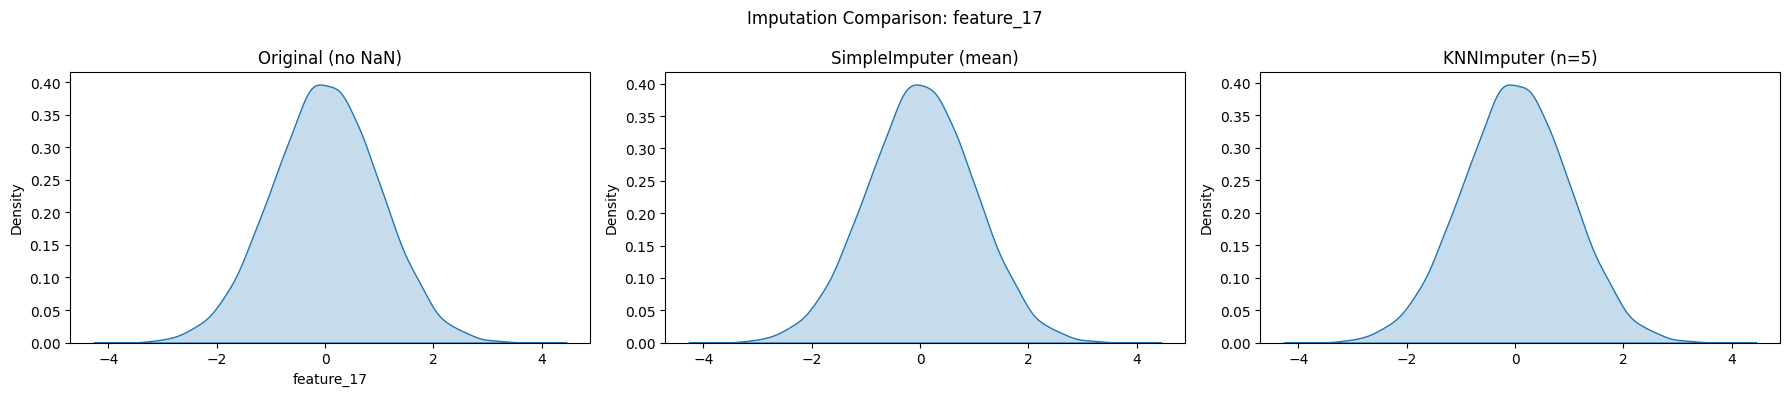

feature_19: 25.34% missing


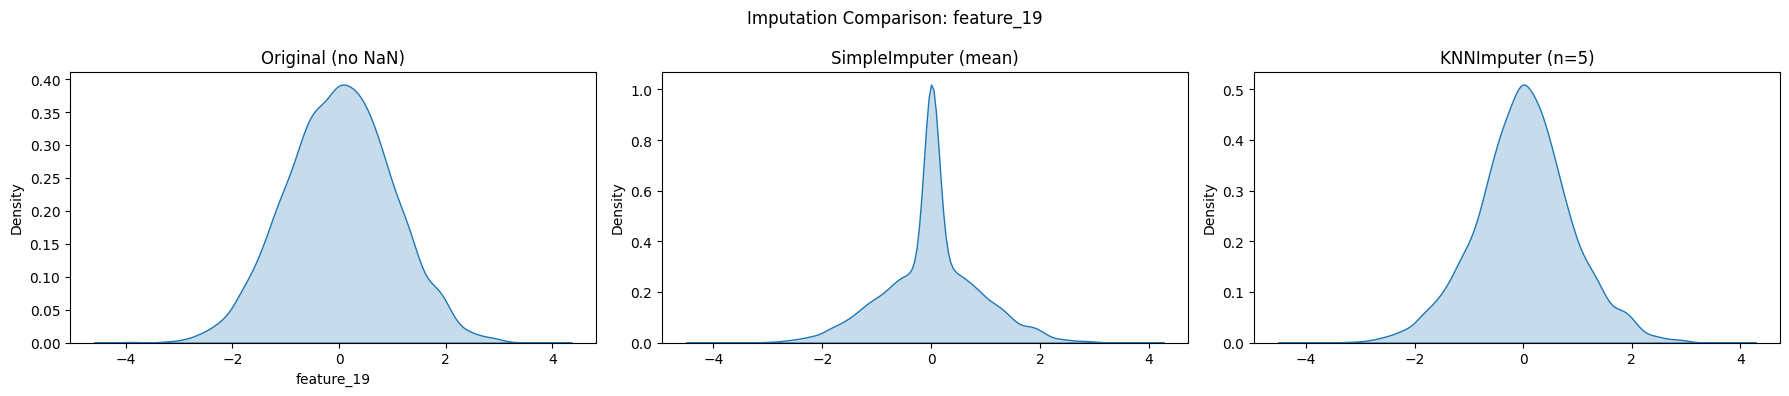

feature_20: 15.6% missing


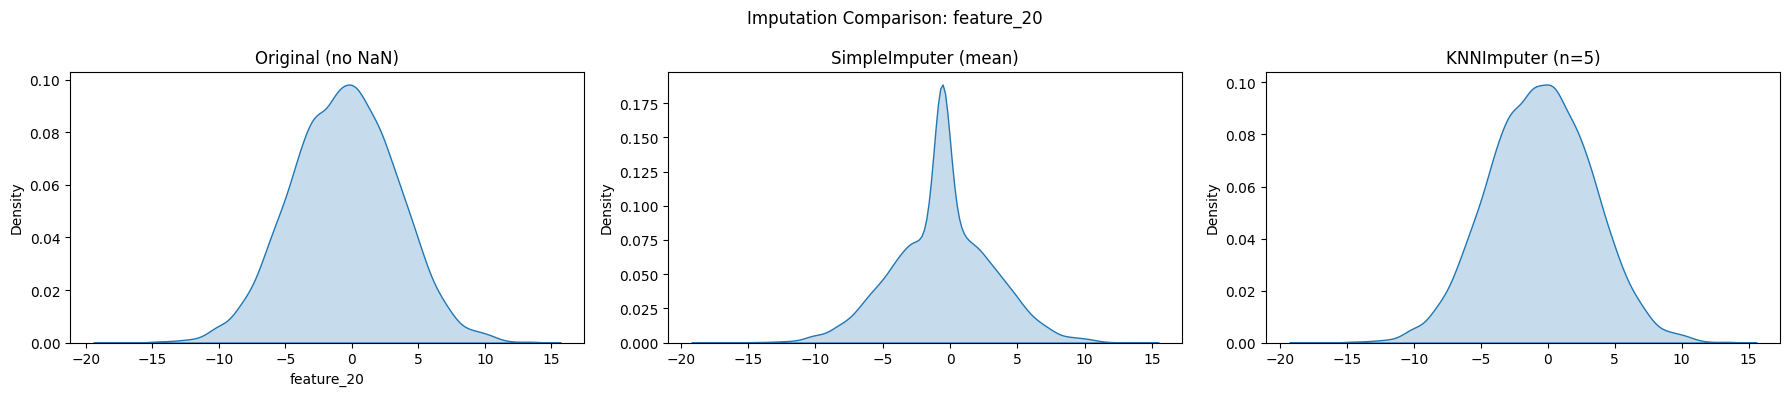

feature_21: 55.67% missing
High missing rate (> 50%) — consider dropping the column, but plots are still shown.


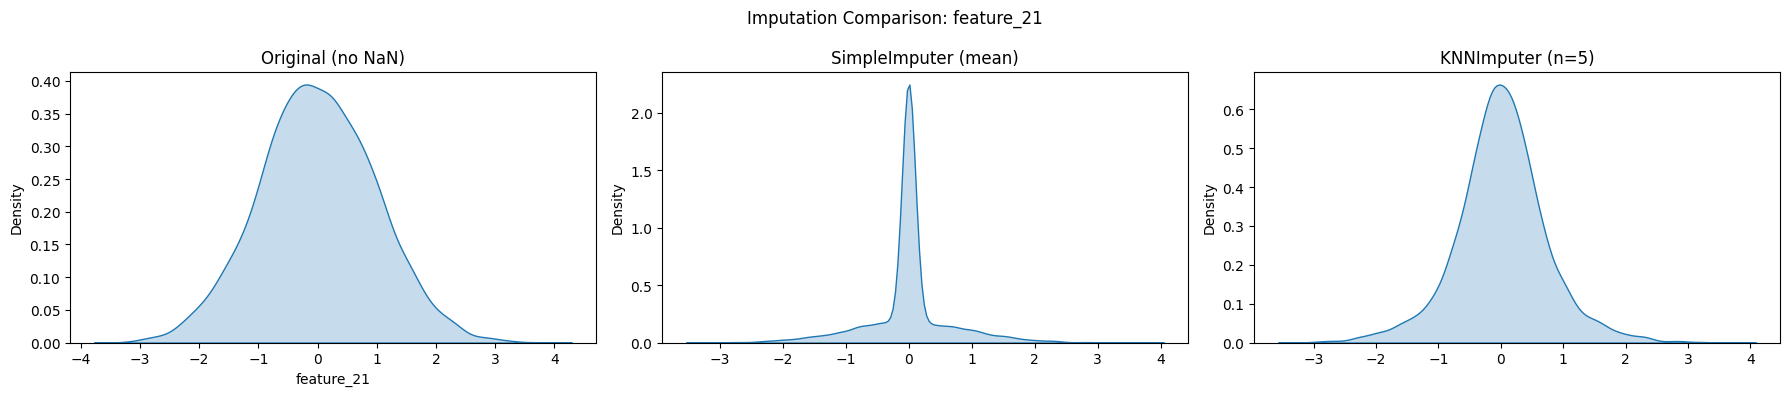

feature_24: 33.44% missing


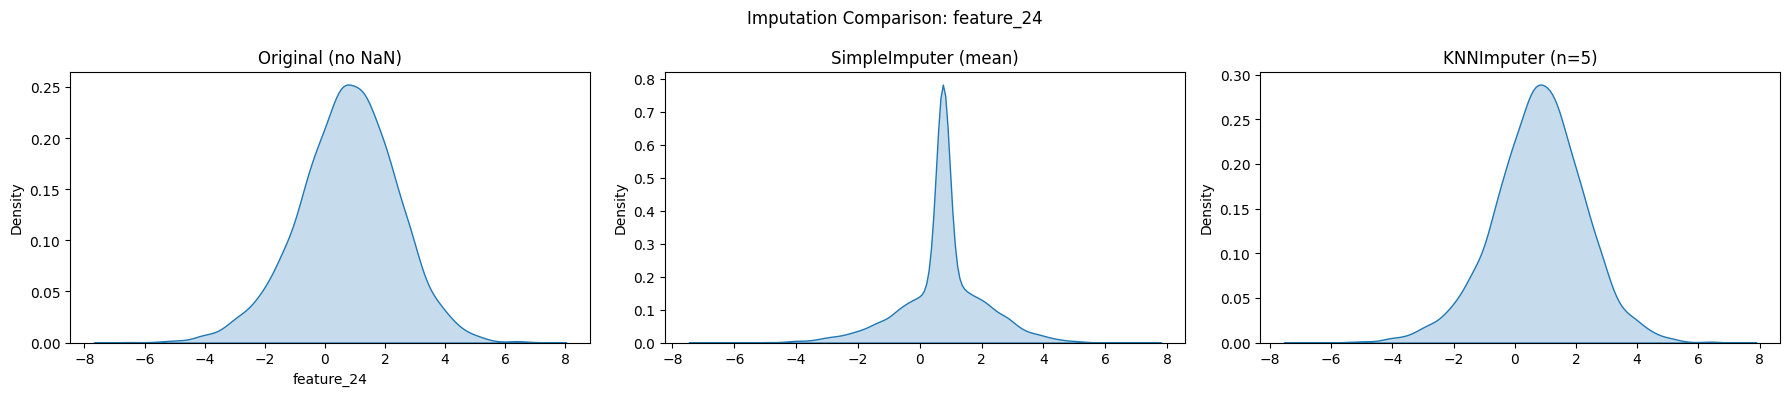

In [13]:
# Loop through all columns with missing values and compare imputation methods (SimpleImputer vs KNNImputer) using KDE plots
for cols in cols_with_missing:
    compare_imputations_smart(df_train, cols)

feature_0: 11.23% missing


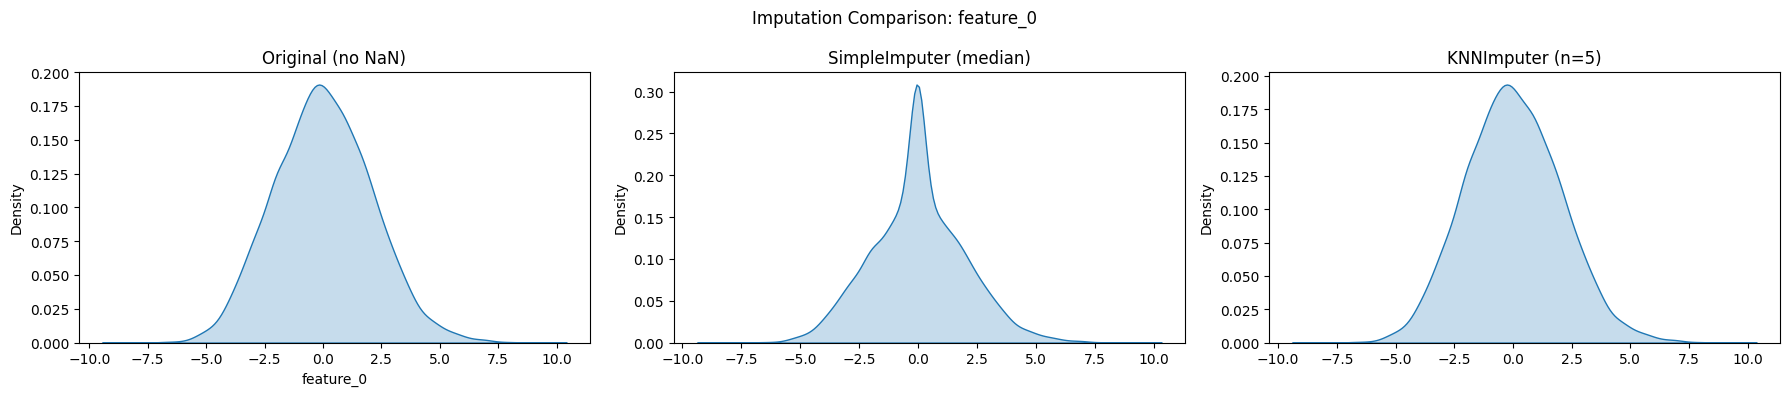

feature_1: 15.34% missing


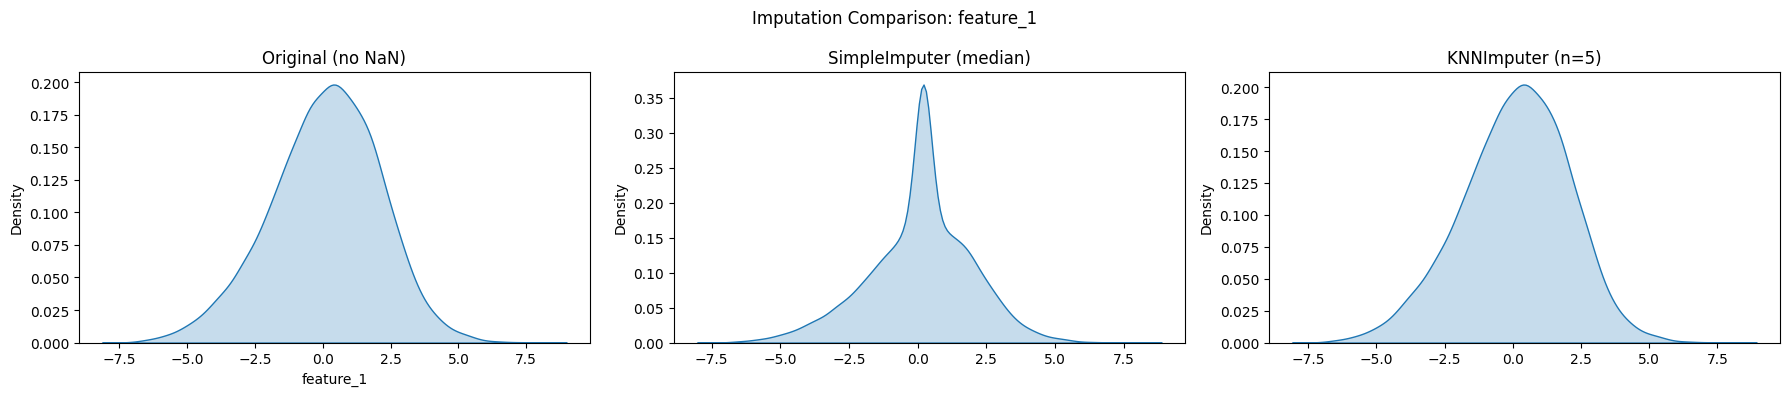

feature_3: 14.34% missing


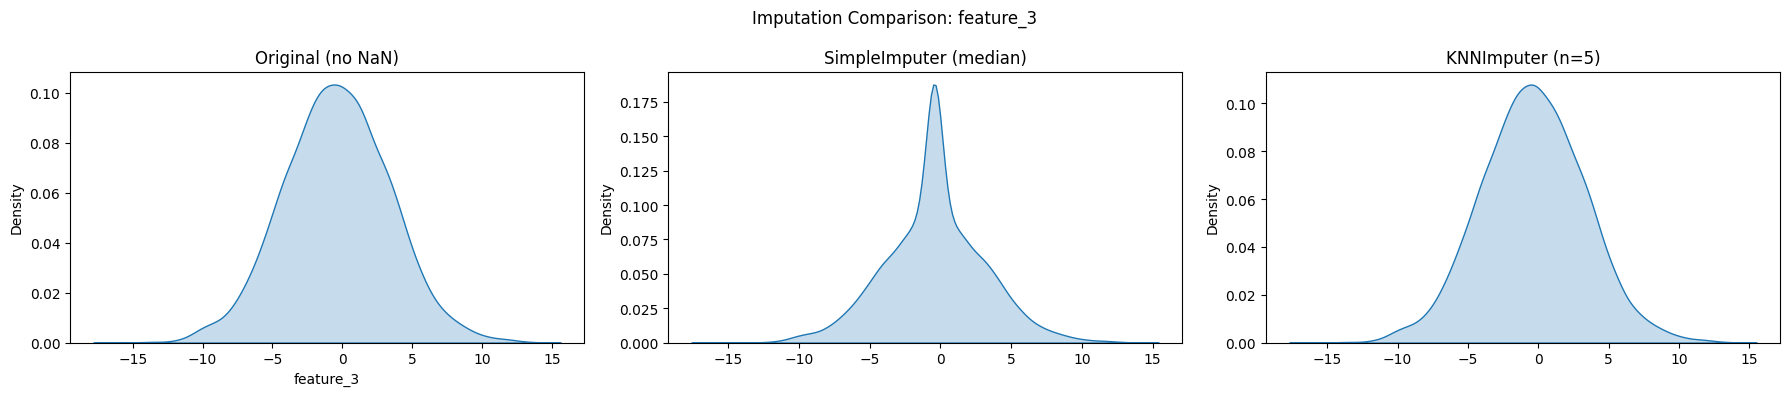

feature_5: 25.34% missing


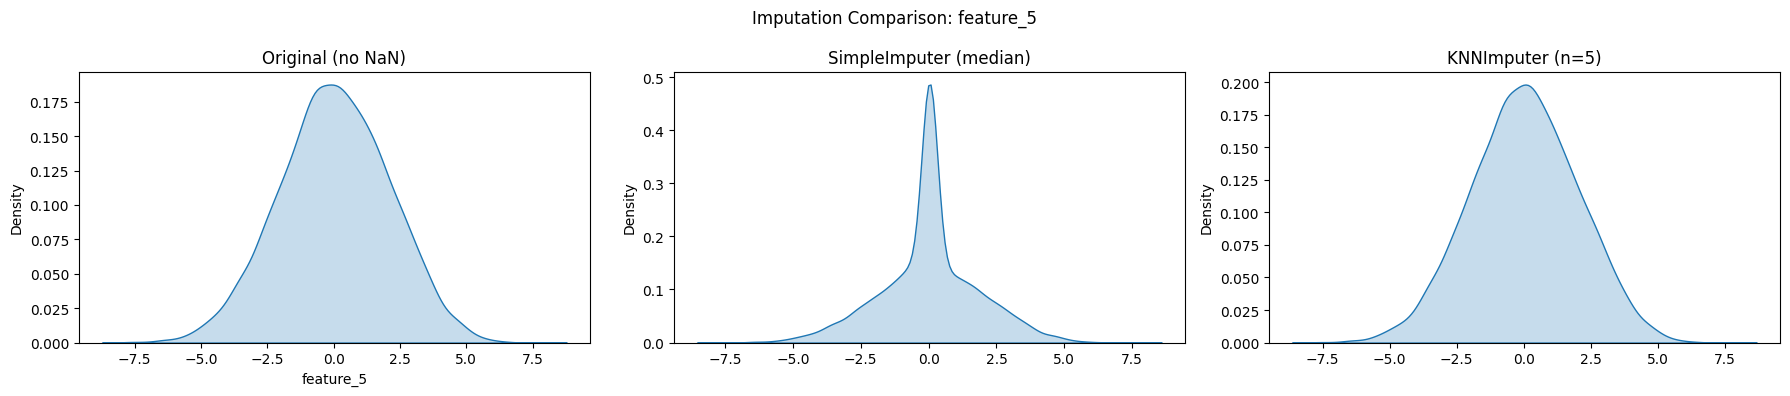

feature_12: 63.46% missing
High missing rate (> 50%) — consider dropping the column, but plots are still shown.


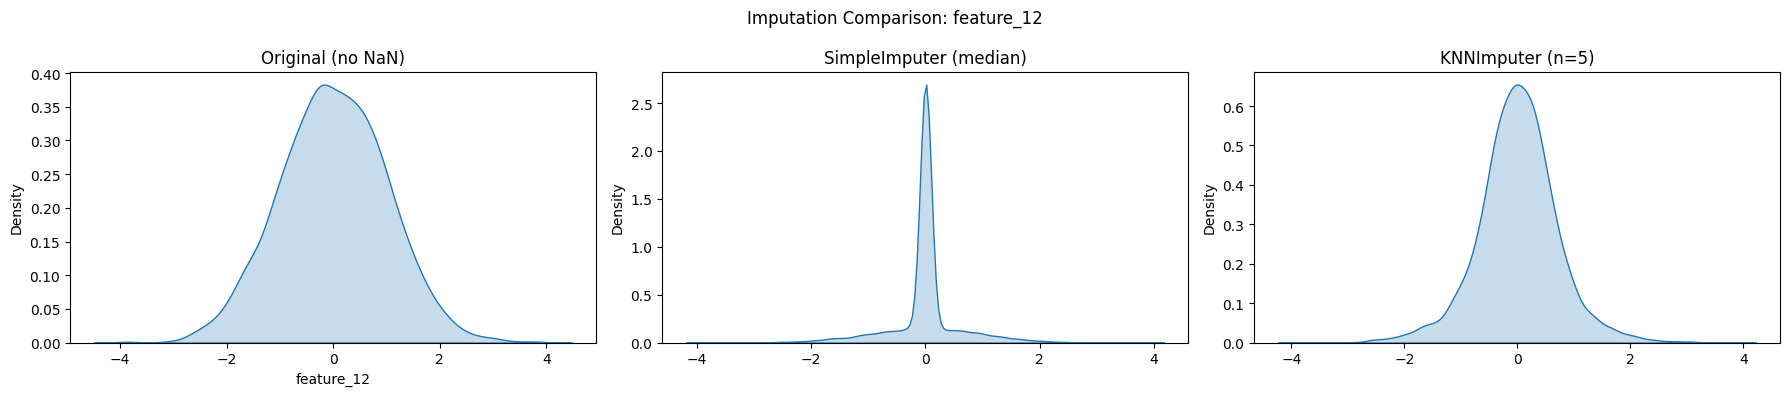

feature_14: 44.64% missing


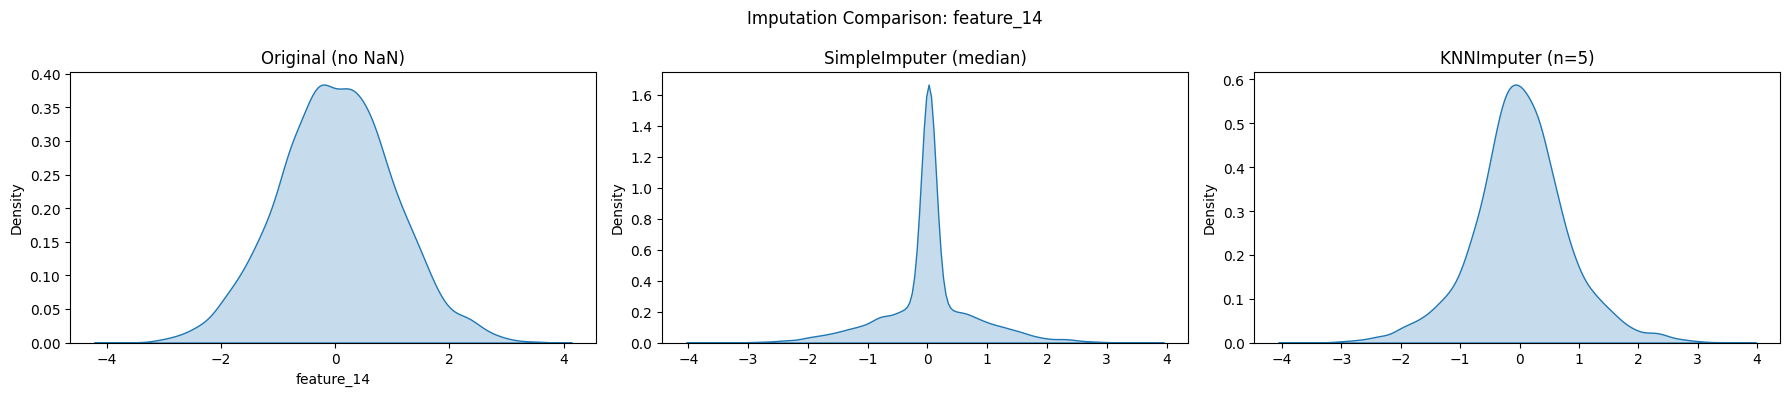

feature_15: 34.34% missing


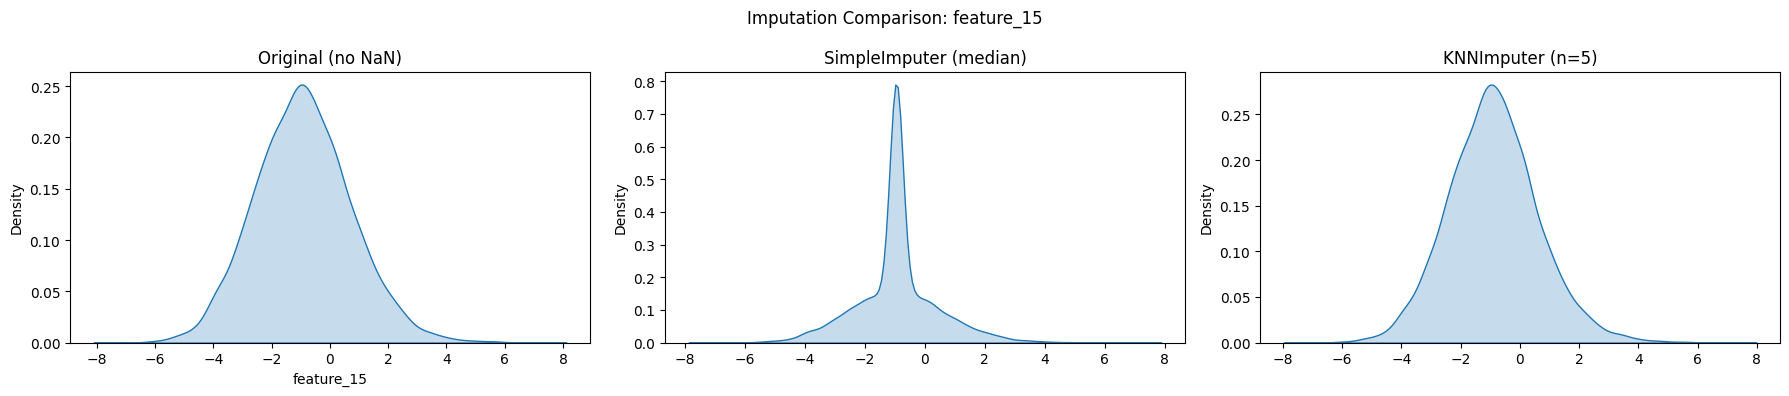

feature_16: 0.53% missing


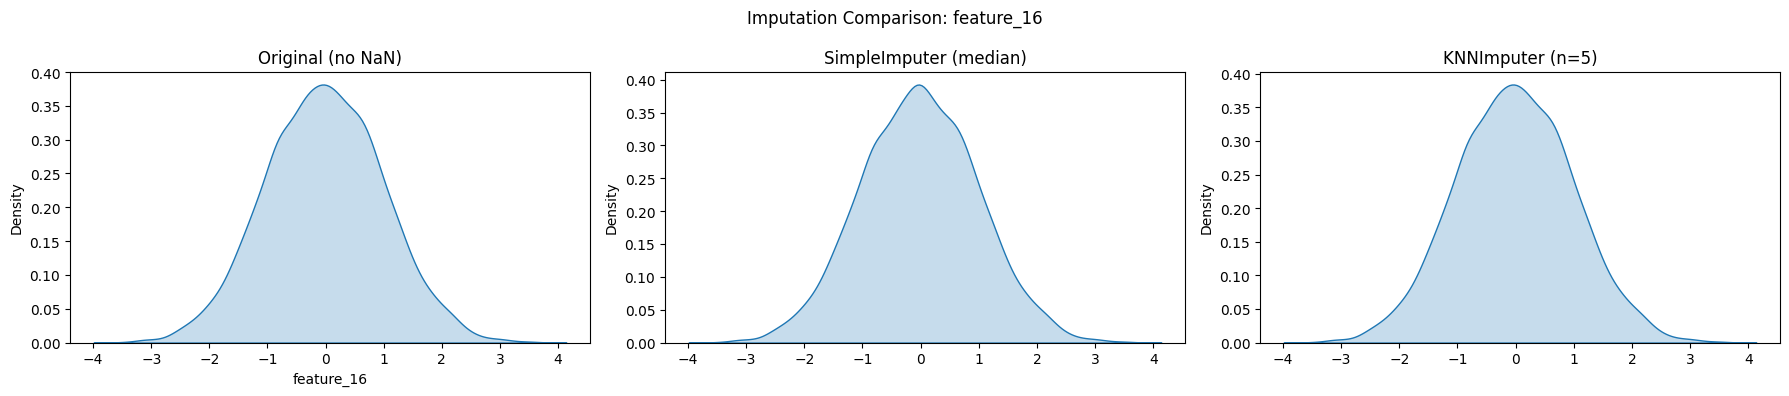

feature_17: 0.13% missing


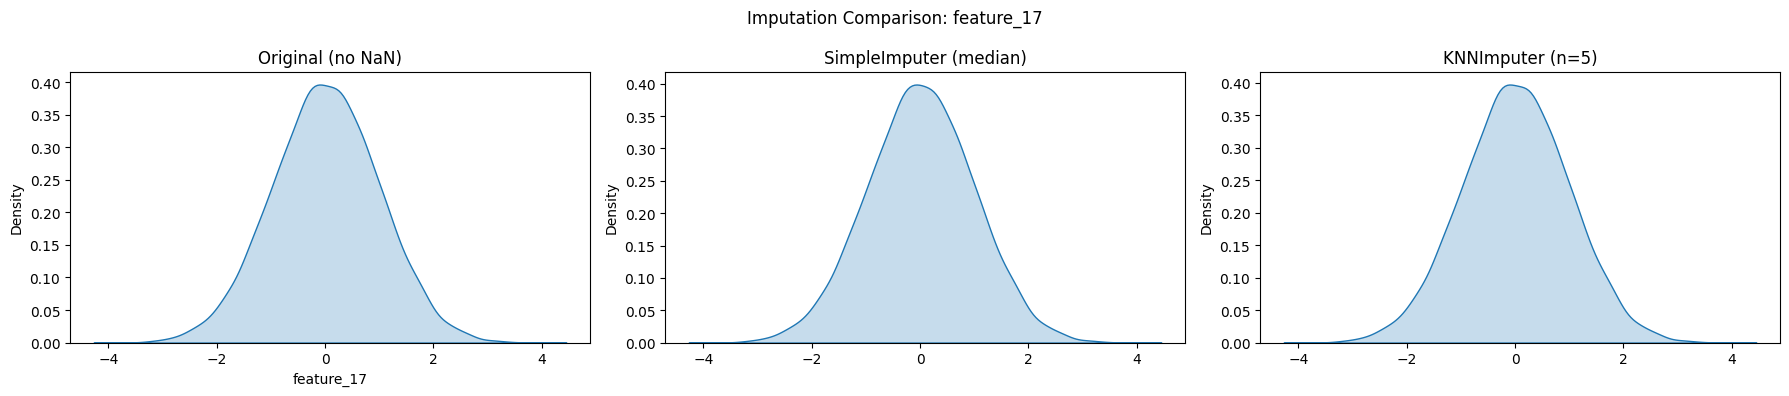

feature_19: 25.34% missing


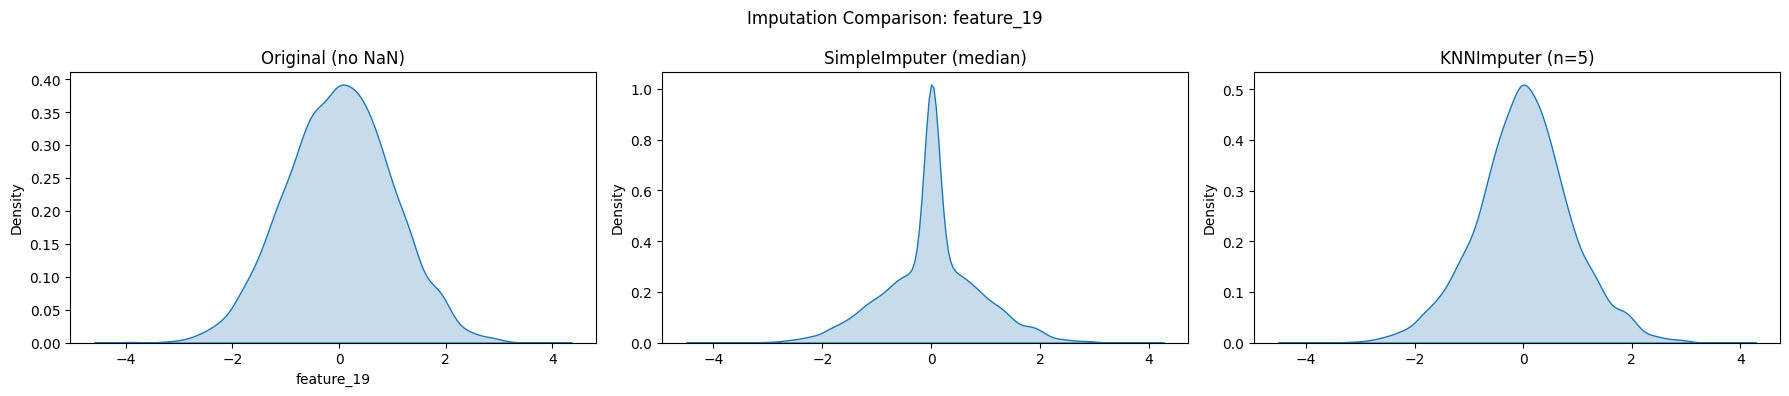

feature_20: 15.6% missing


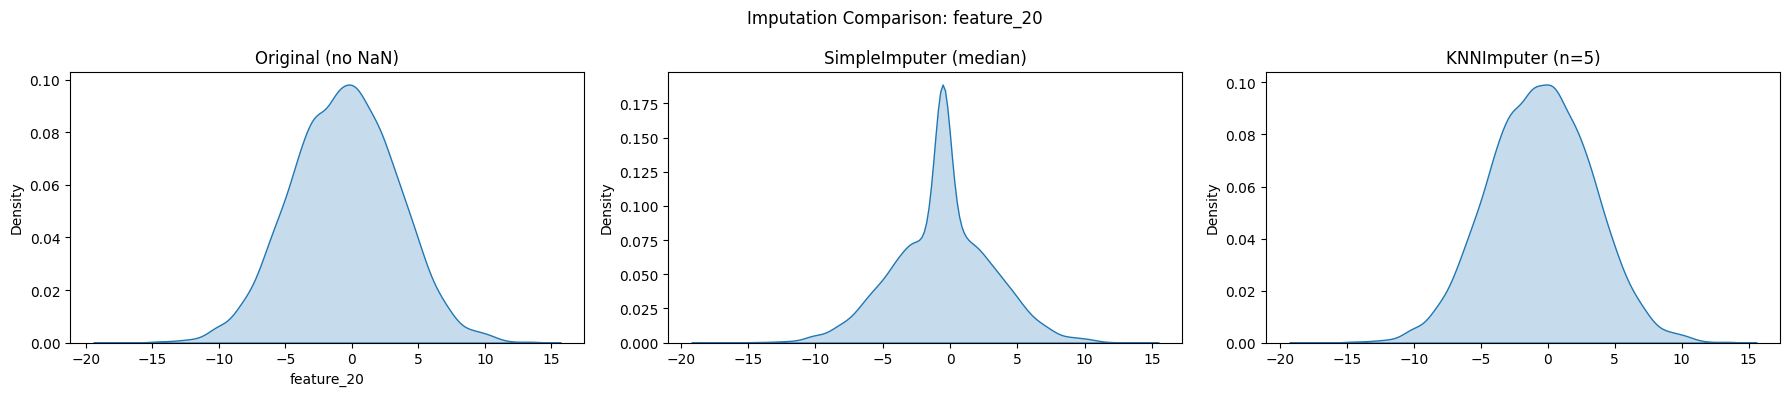

feature_21: 55.67% missing
High missing rate (> 50%) — consider dropping the column, but plots are still shown.


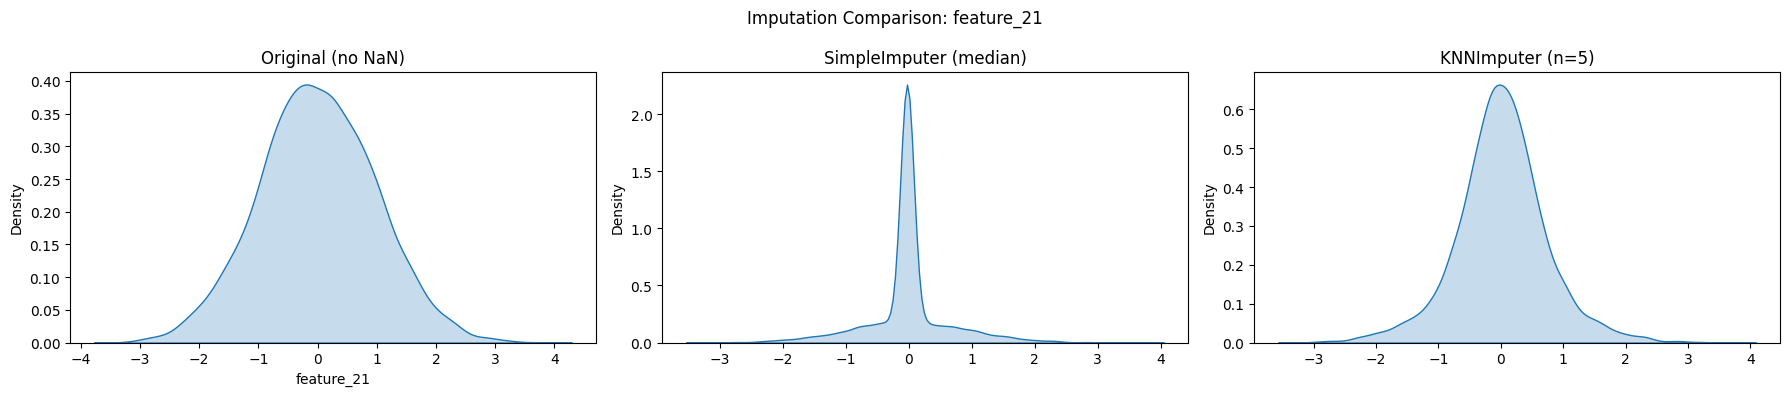

feature_24: 33.44% missing


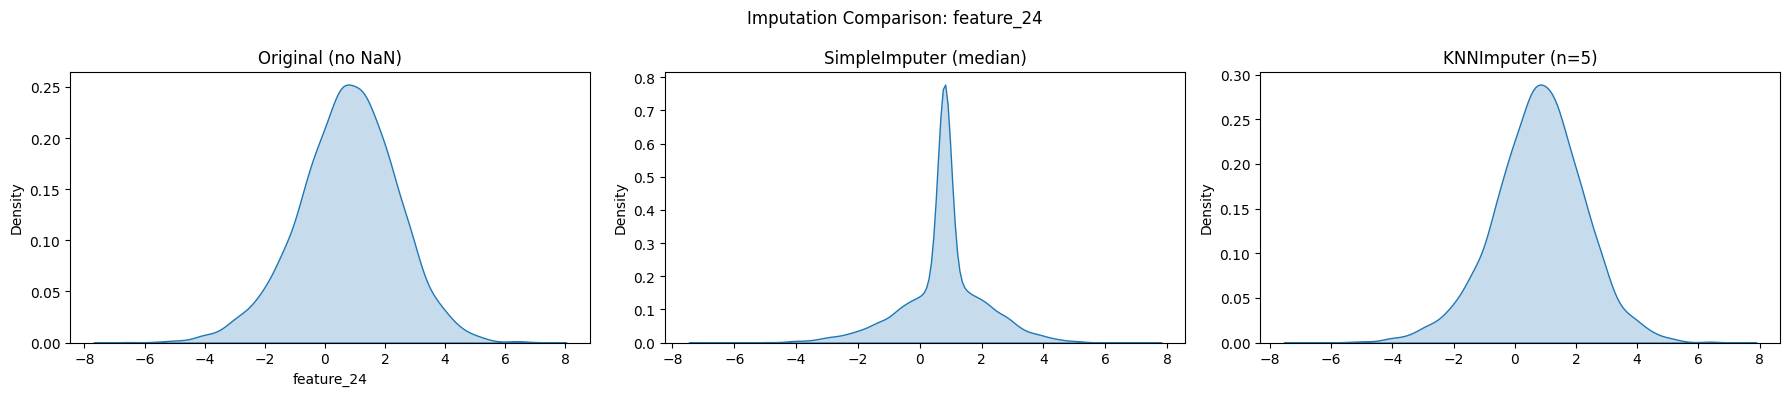

In [14]:
# Loop through all columns with missing values and compare imputation methods using "median" strategy for SimpleImputer and default K=5 for KNNImputer
for cols in cols_with_missing:
    compare_imputations_smart(df_train, cols, "median")

feature_0: 11.23% missing


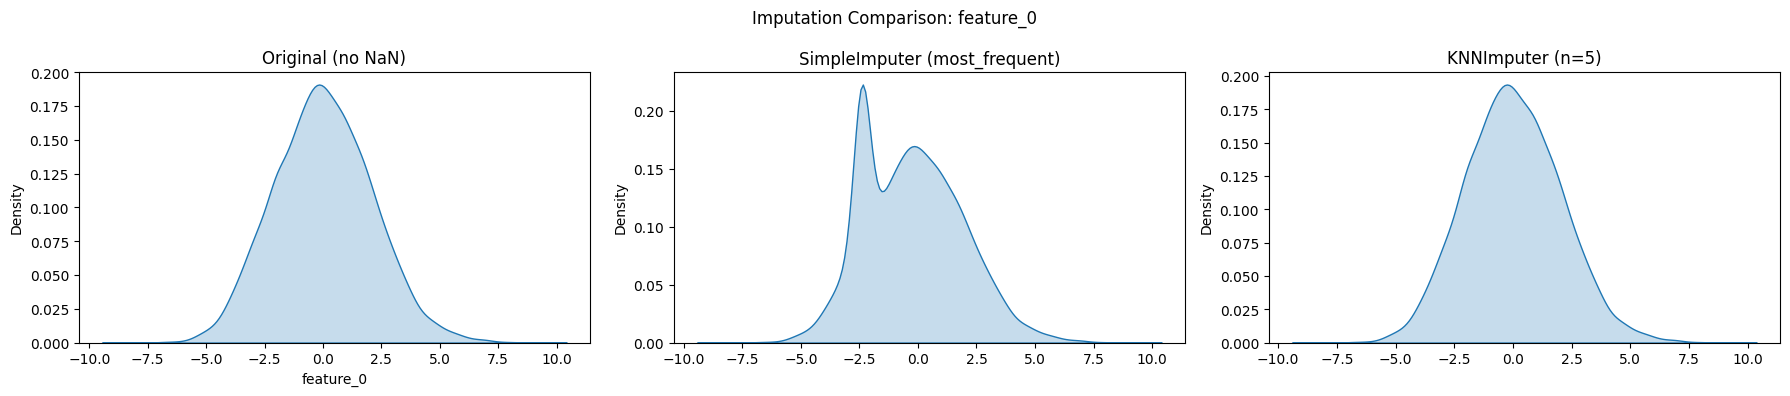

feature_1: 15.34% missing


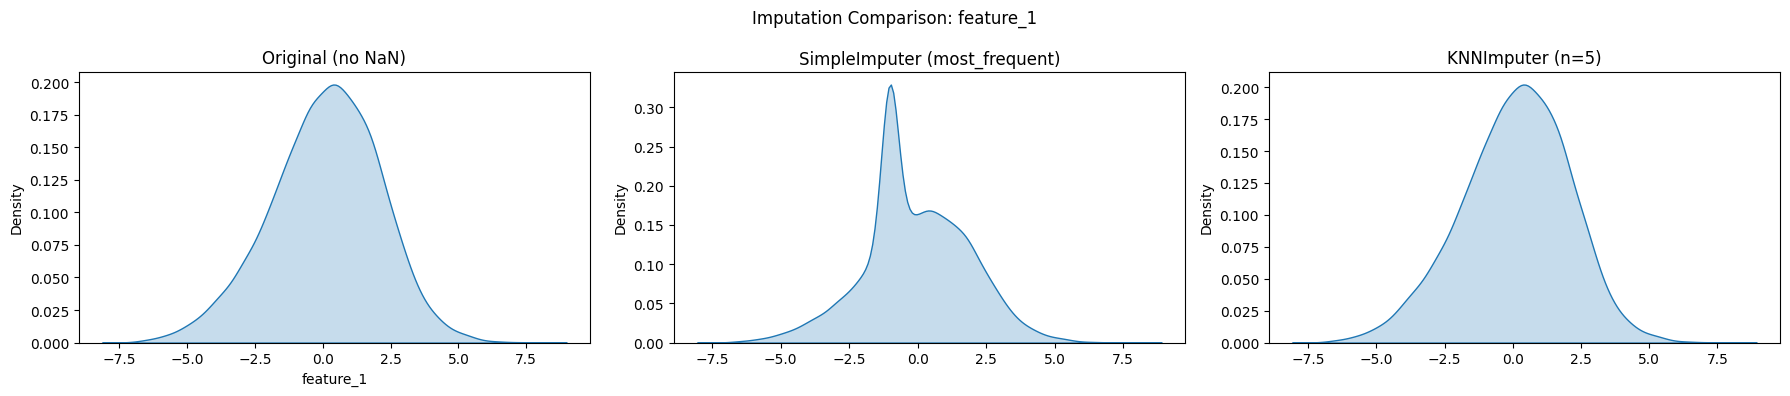

feature_3: 14.34% missing


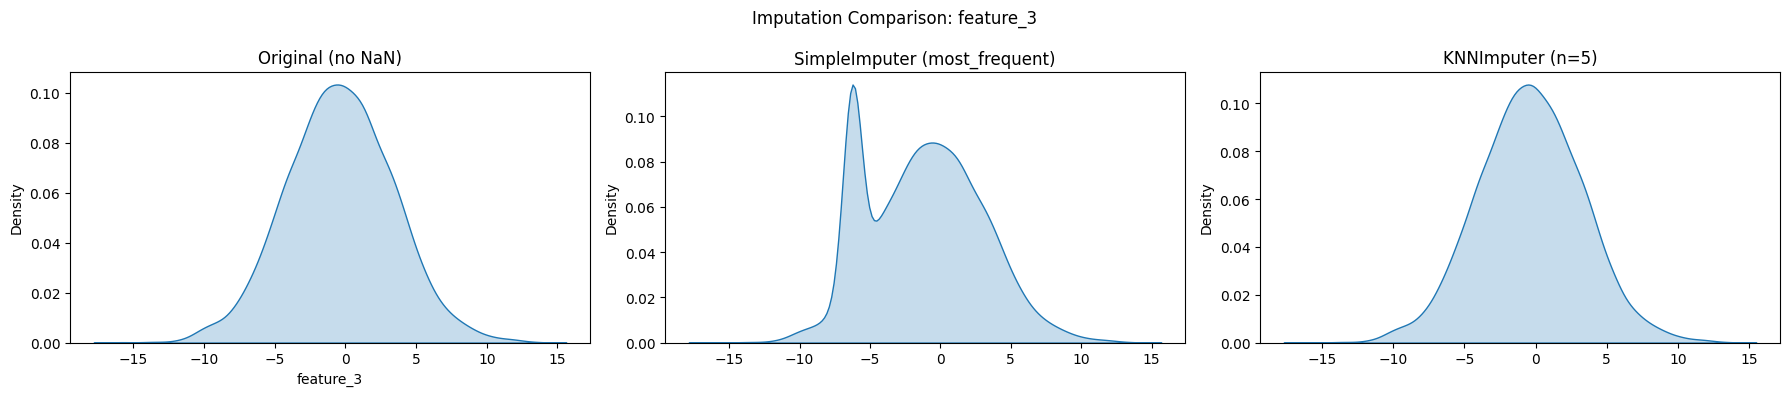

feature_5: 25.34% missing


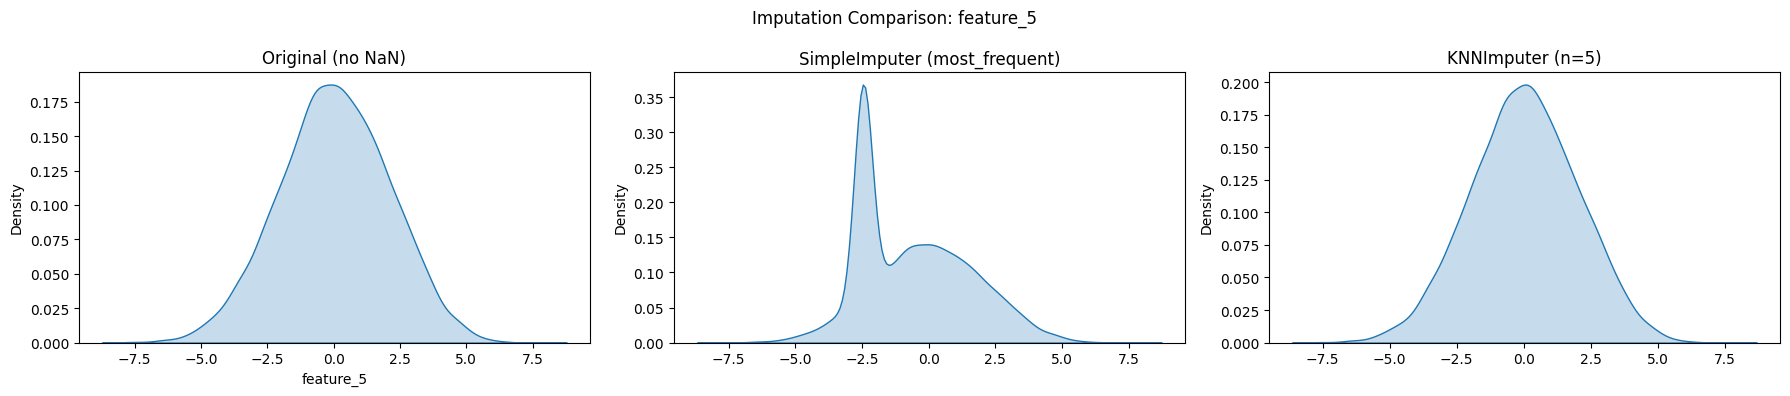

feature_12: 63.46% missing
High missing rate (> 50%) — consider dropping the column, but plots are still shown.


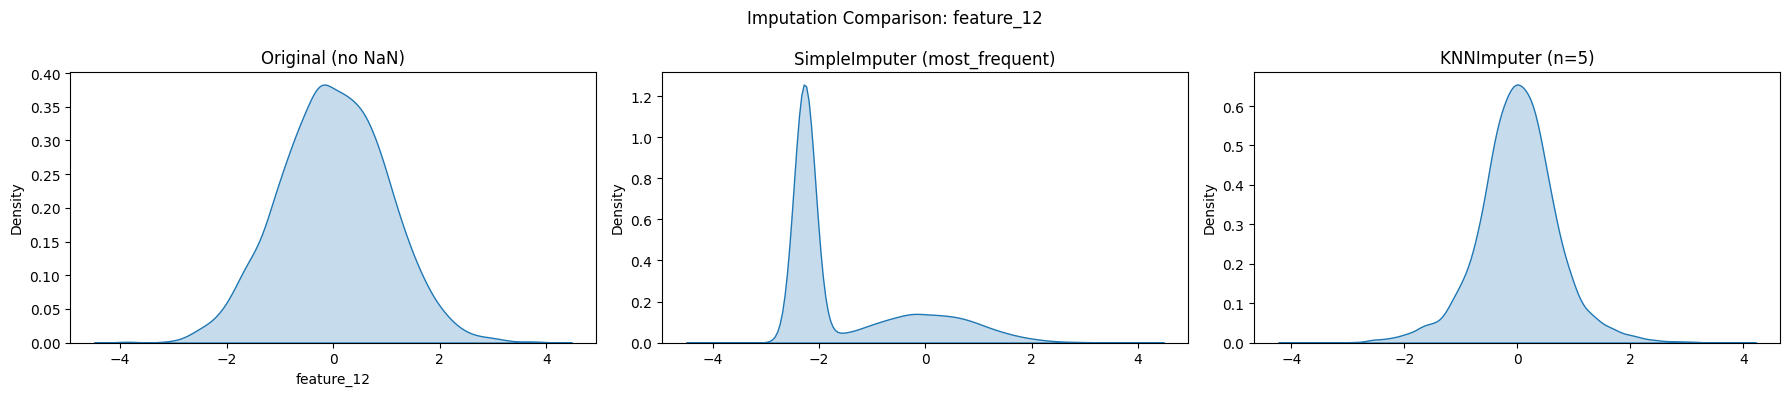

feature_14: 44.64% missing


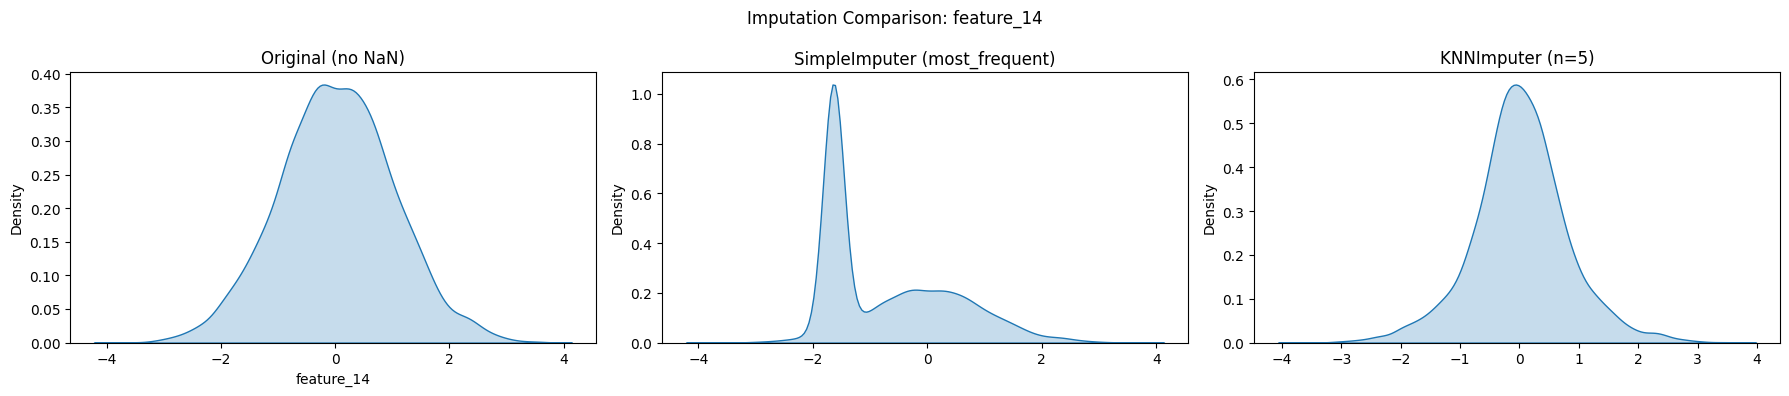

feature_15: 34.34% missing


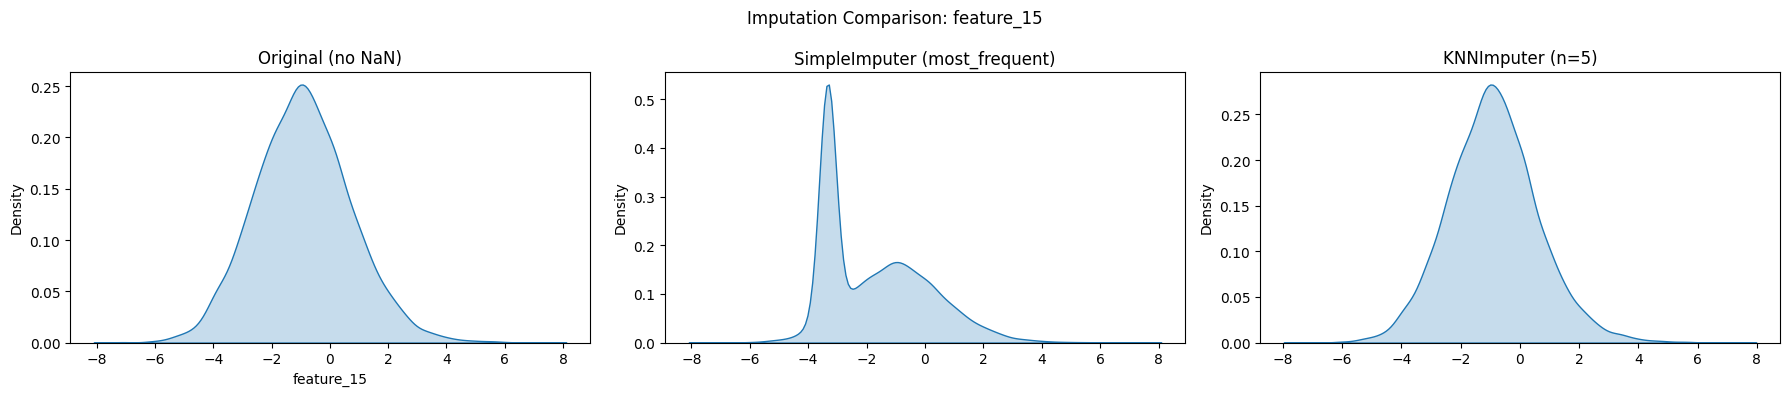

feature_16: 0.53% missing


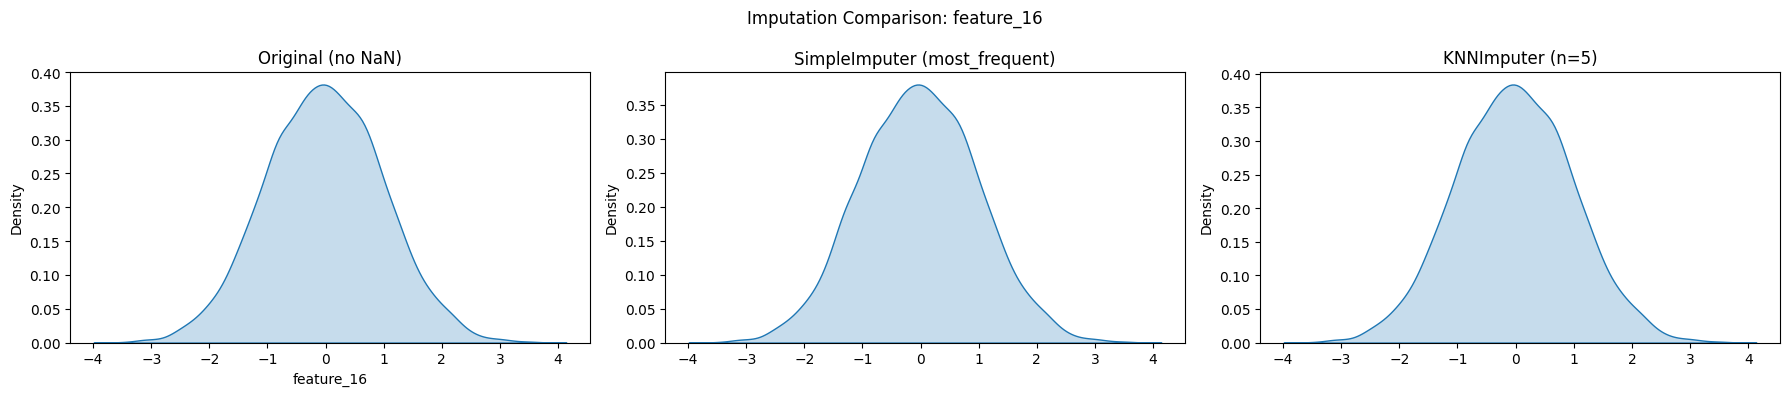

feature_17: 0.13% missing


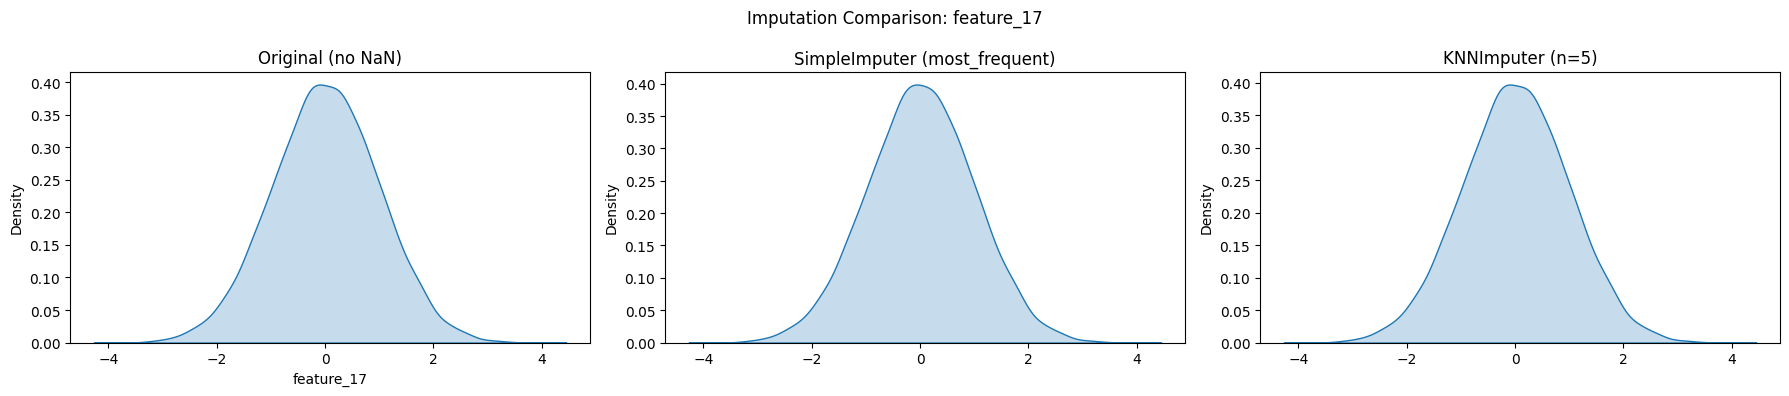

feature_19: 25.34% missing


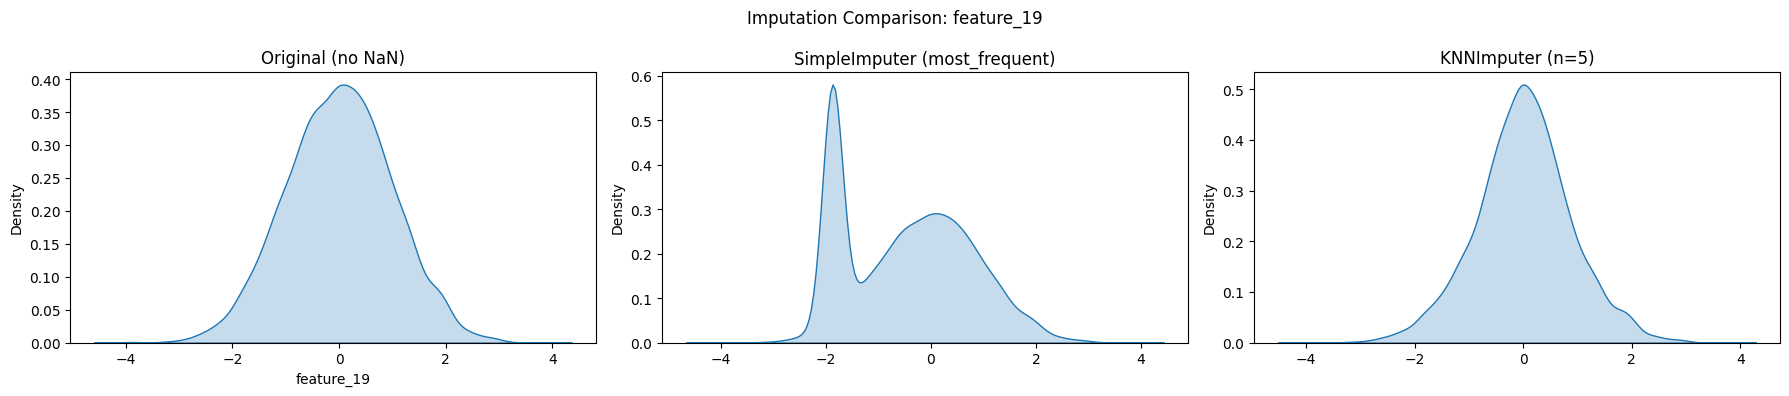

feature_20: 15.6% missing


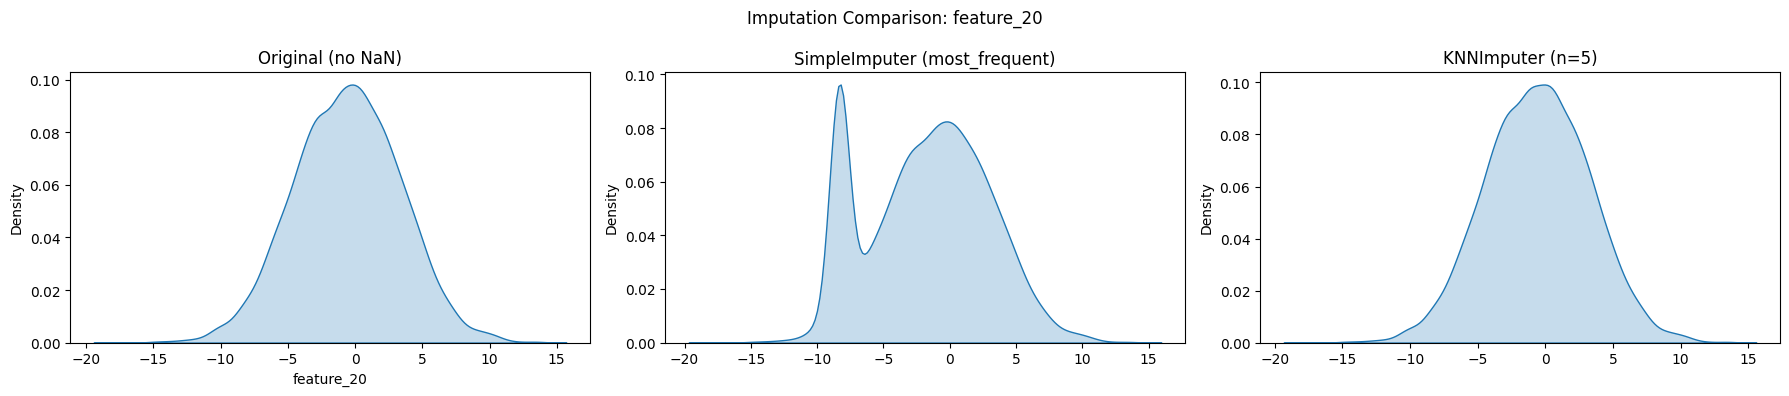

feature_21: 55.67% missing
High missing rate (> 50%) — consider dropping the column, but plots are still shown.


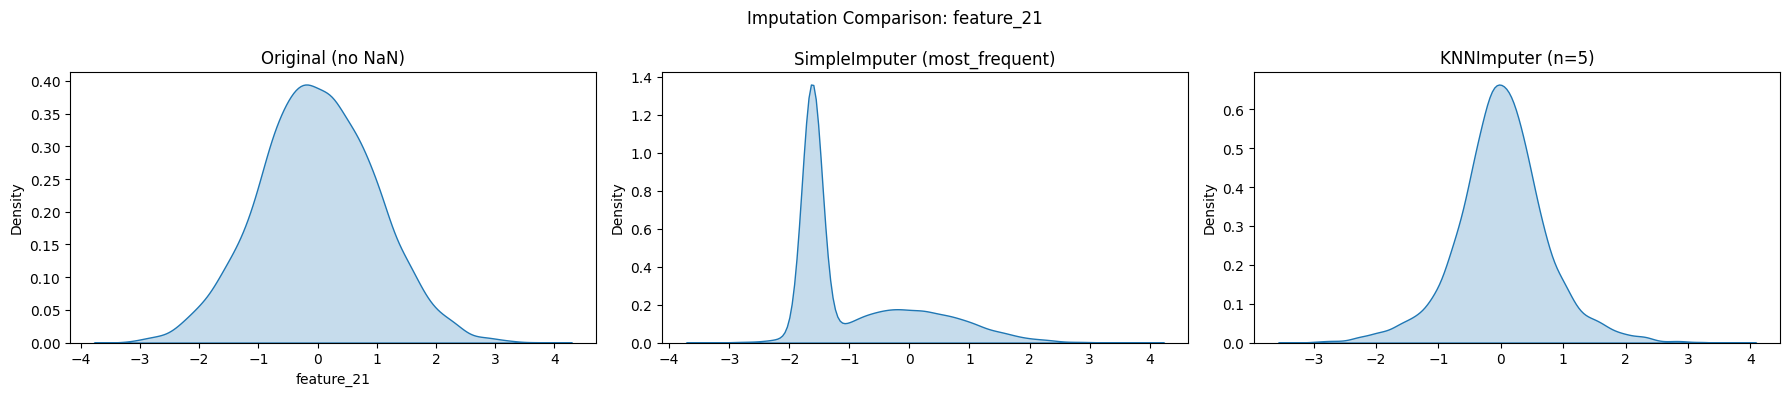

feature_24: 33.44% missing


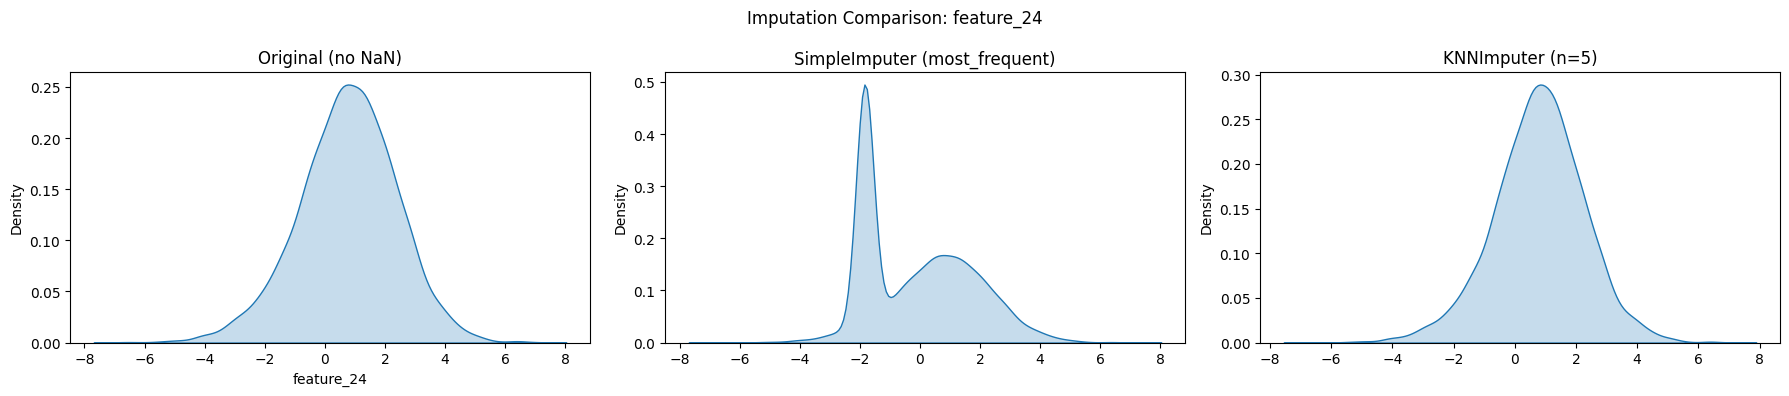

In [15]:
# Loop through all columns with missing values and compare imputation methods using "most_frequent" strategy for SimpleImputer and default K=5 for KNNImputer
for cols in cols_with_missing:
    compare_imputations_smart(df_train, cols, "most_frequent")

feature_0: 11.23% missing


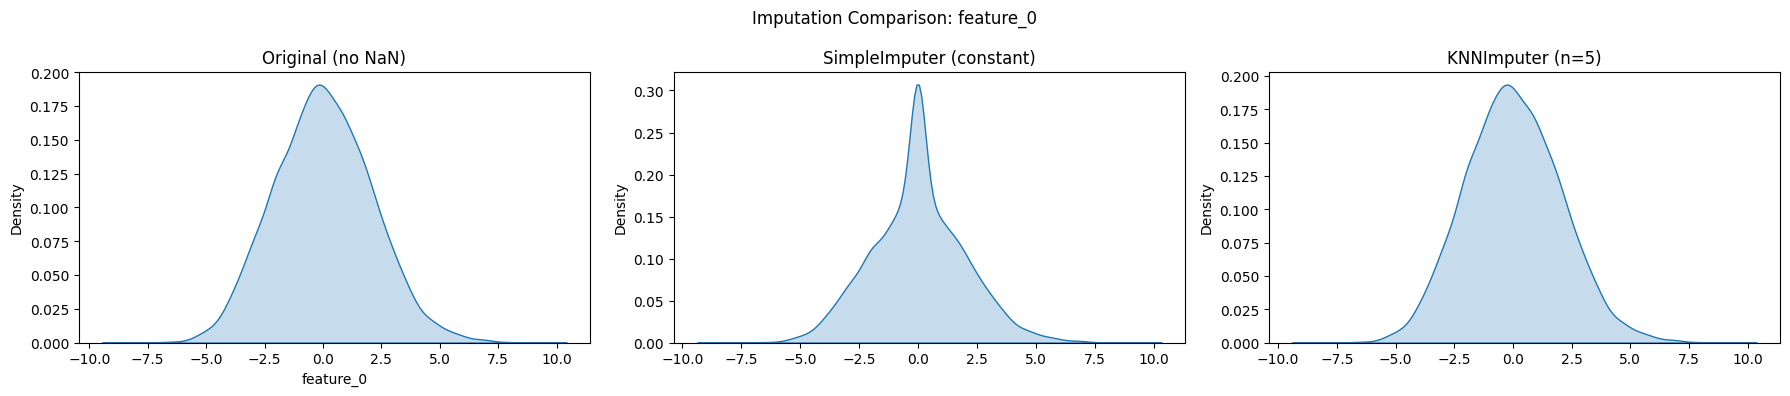

feature_1: 15.34% missing


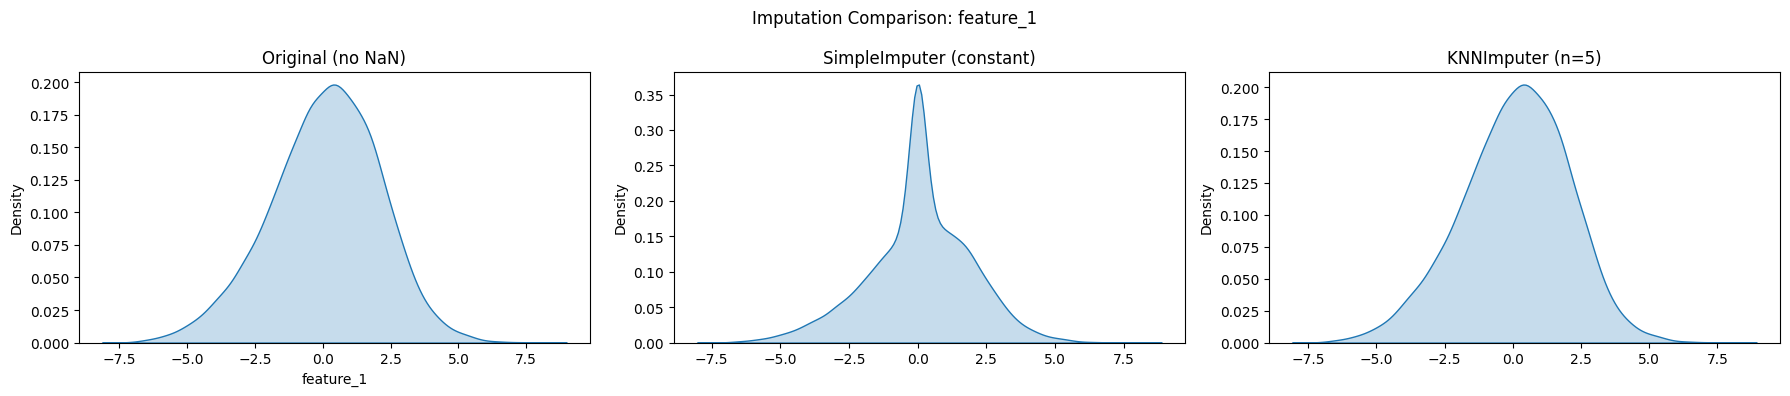

feature_3: 14.34% missing


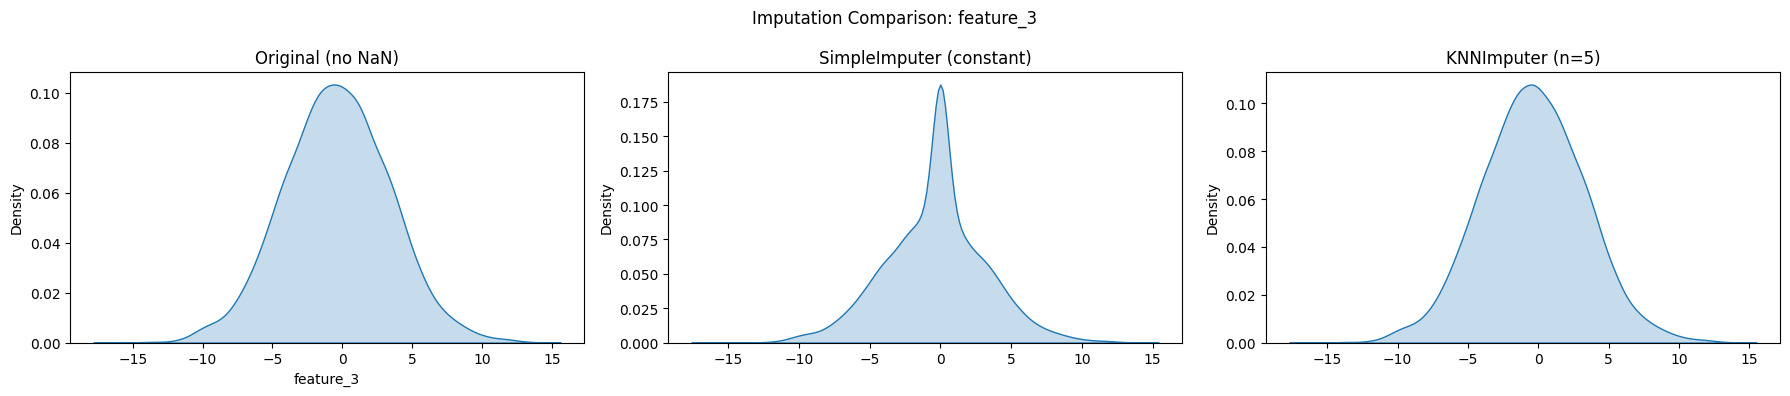

feature_5: 25.34% missing


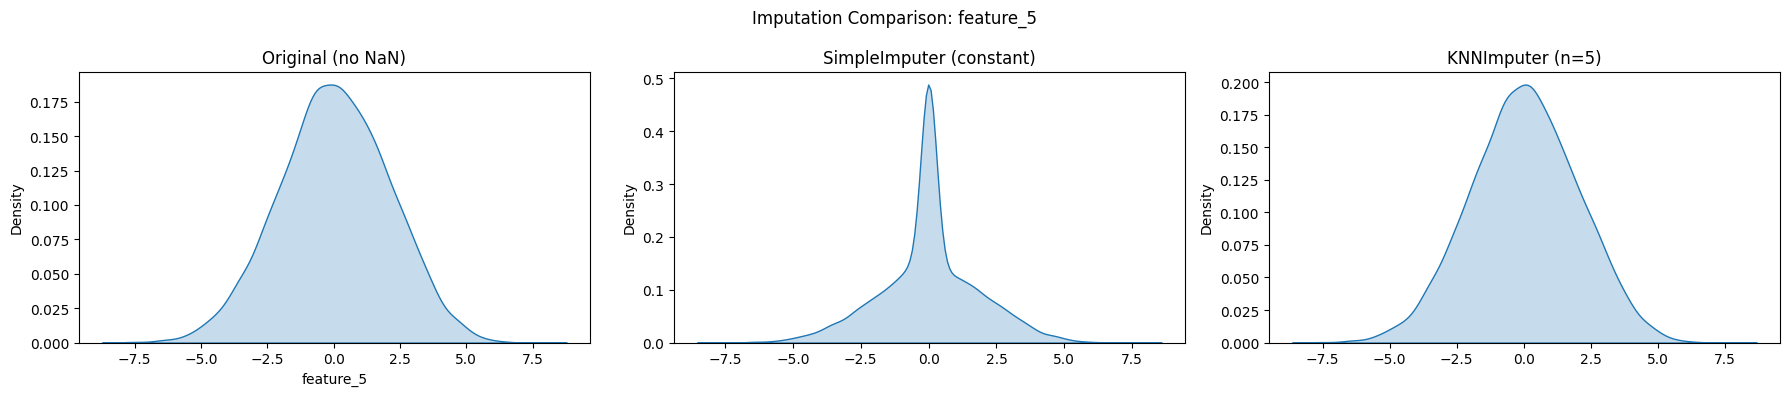

feature_12: 63.46% missing
High missing rate (> 50%) — consider dropping the column, but plots are still shown.


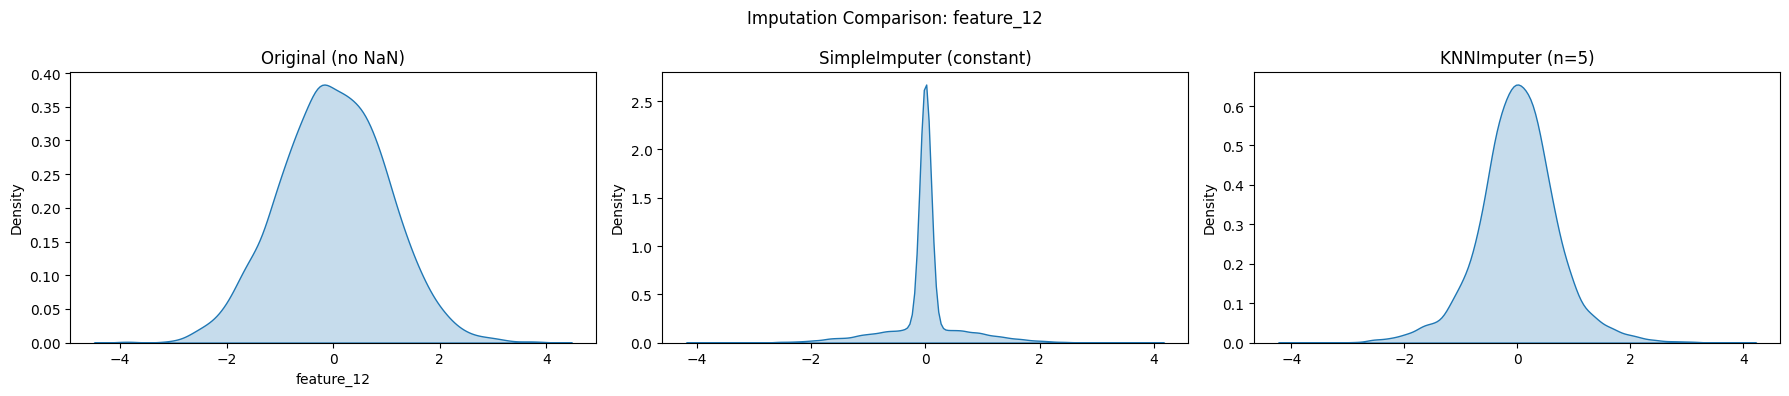

feature_14: 44.64% missing


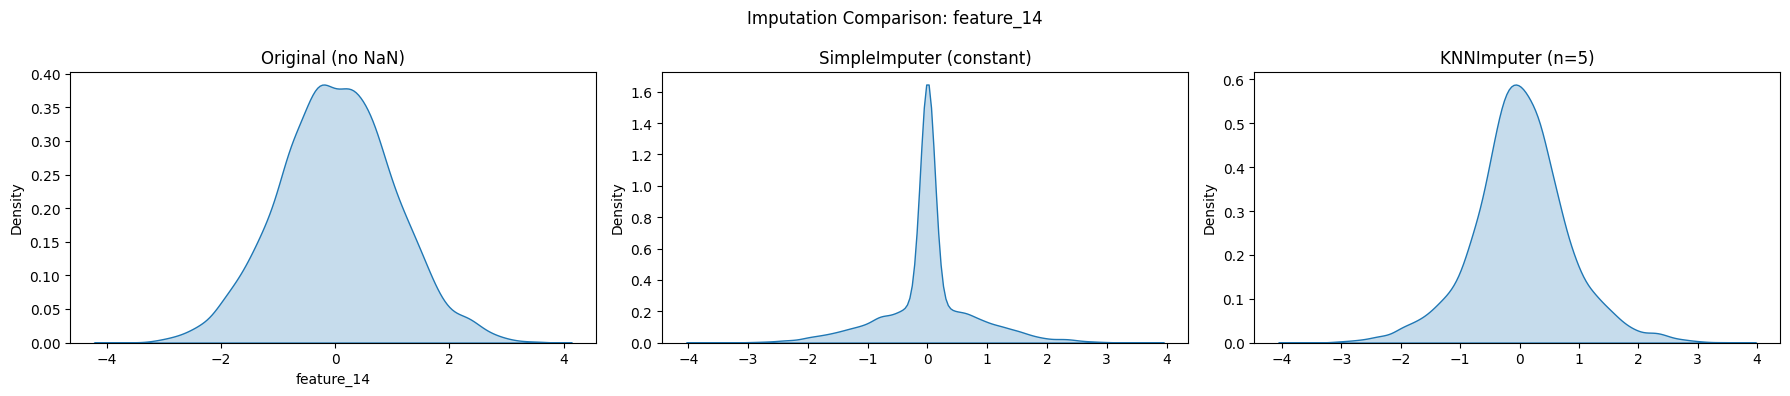

feature_15: 34.34% missing


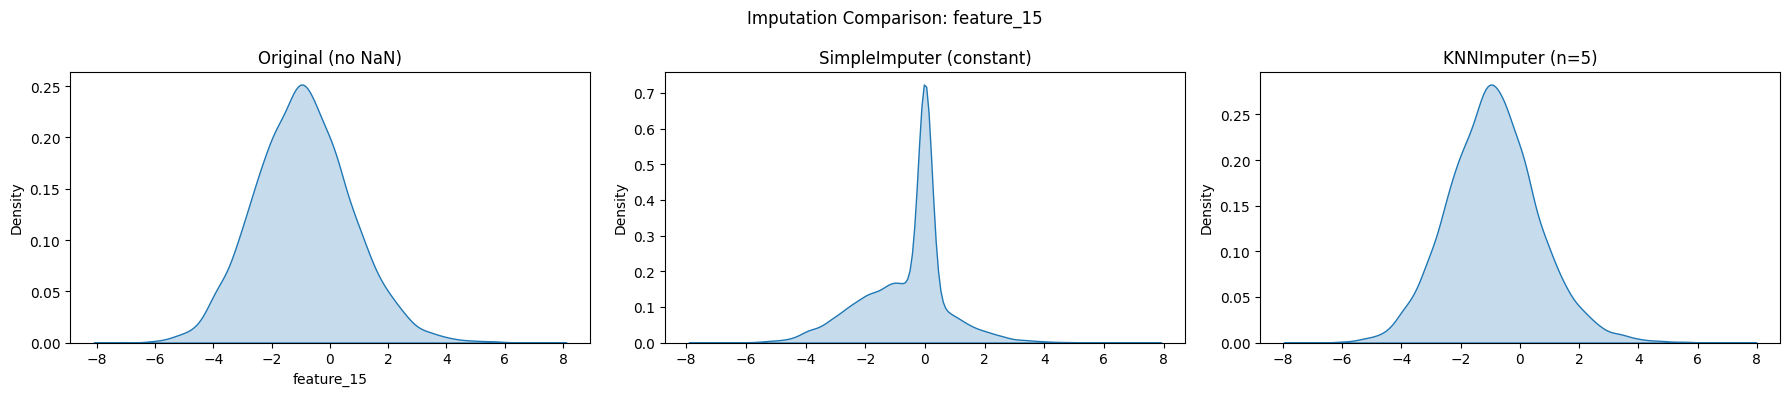

feature_16: 0.53% missing


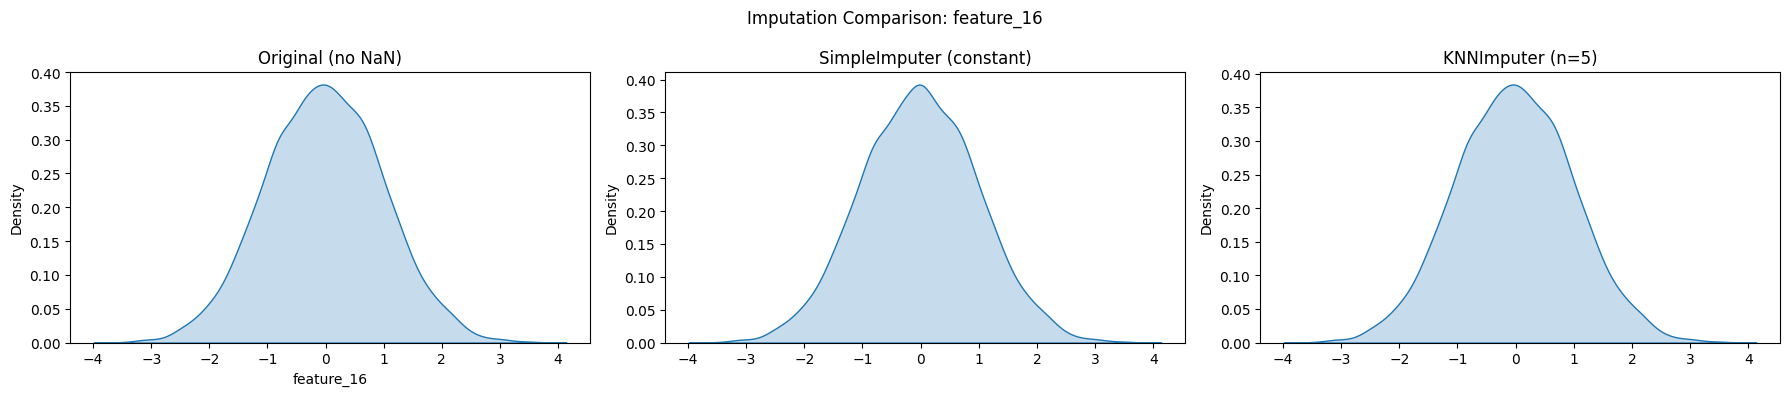

feature_17: 0.13% missing


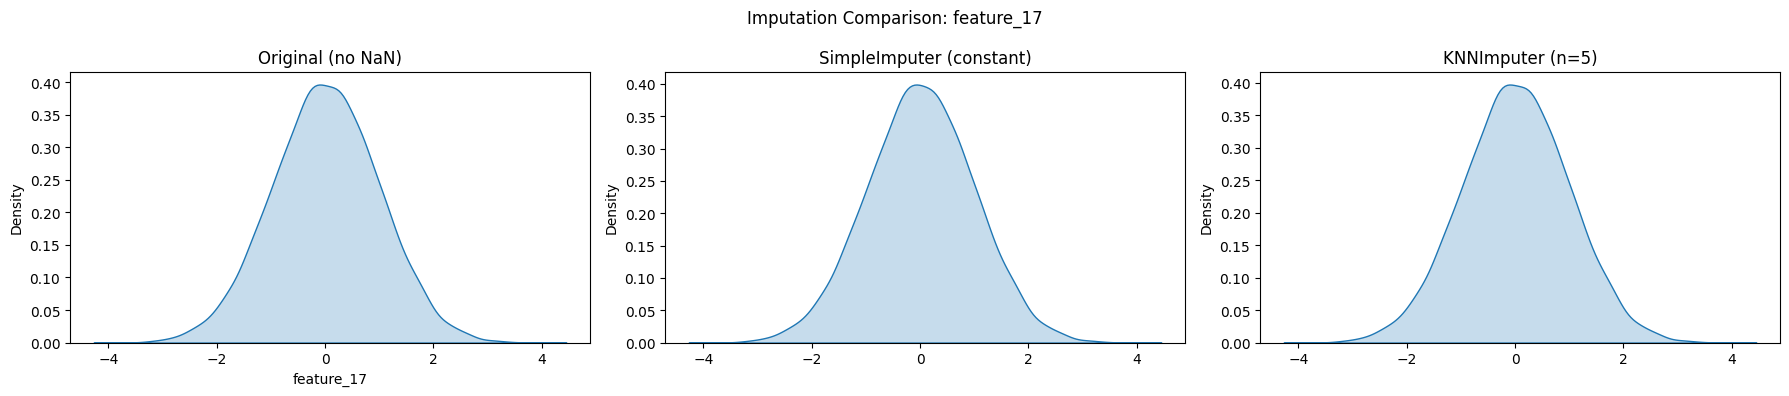

feature_19: 25.34% missing


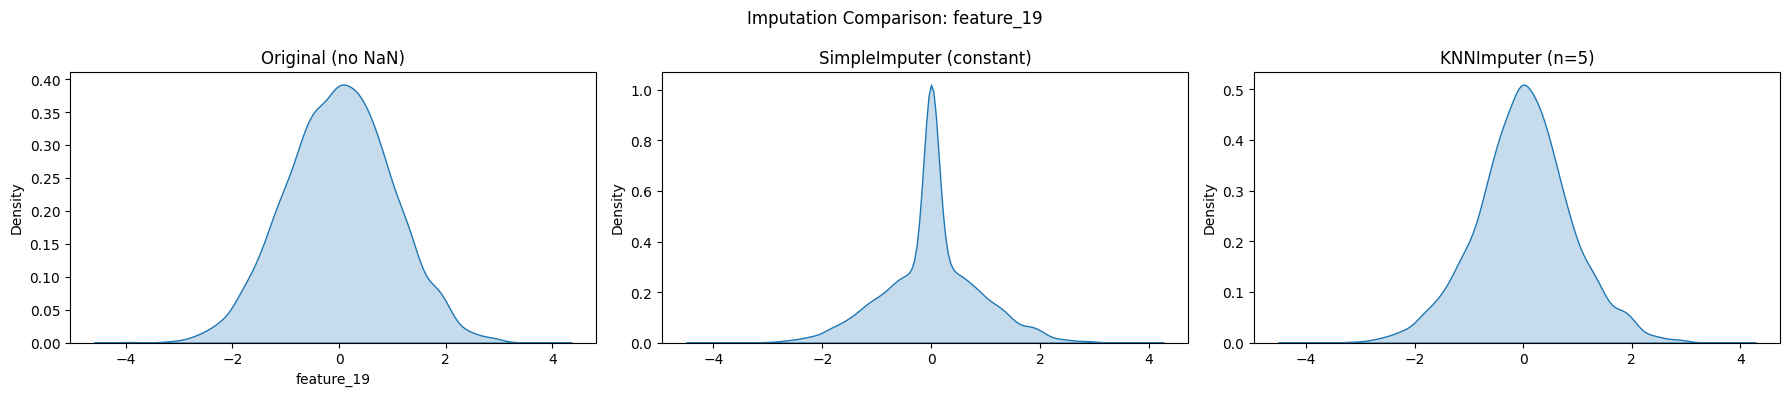

feature_20: 15.6% missing


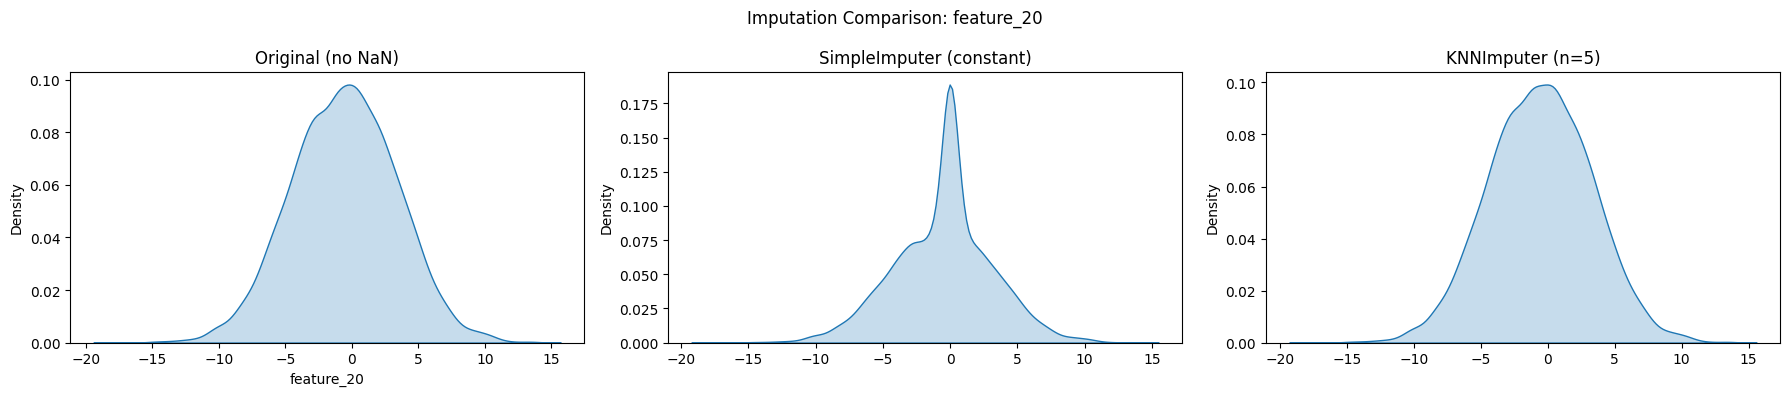

feature_21: 55.67% missing
High missing rate (> 50%) — consider dropping the column, but plots are still shown.


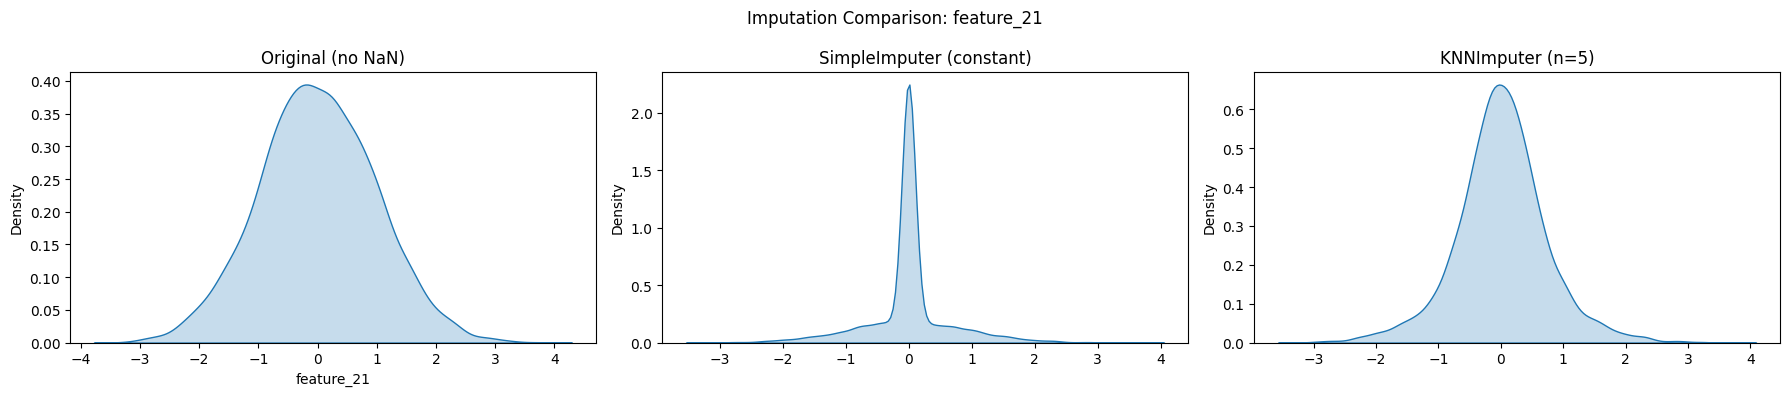

feature_24: 33.44% missing


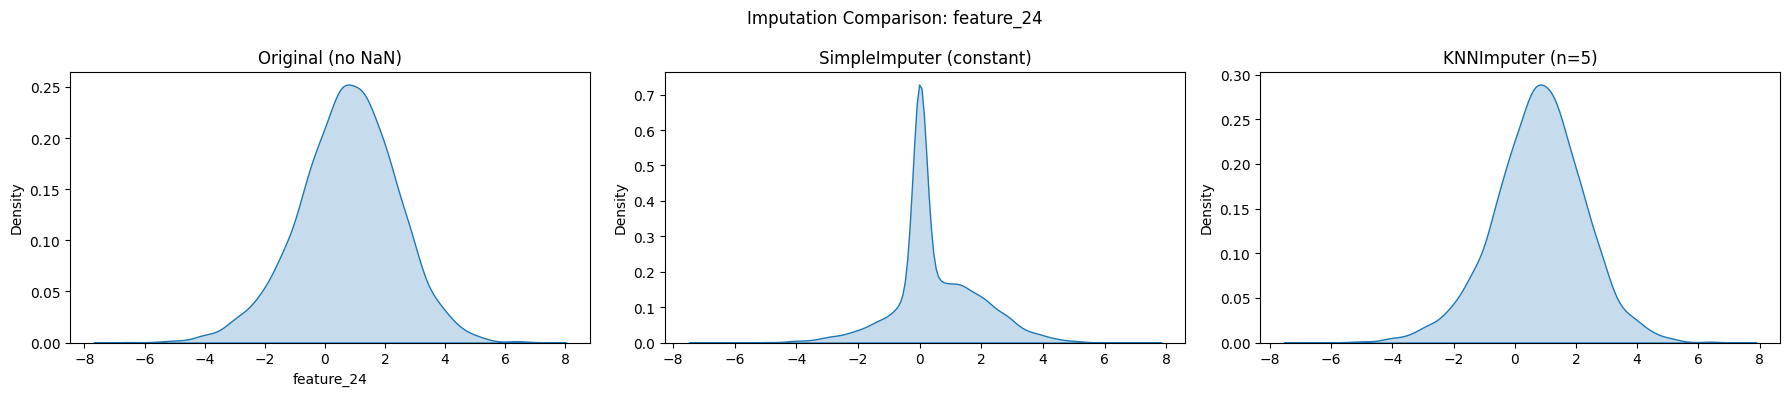

In [16]:
# Loop through all columns with missing values and compare imputation methods using "constant" strategy for SimpleImputer and default K=5 for KNNImputer
for cols in cols_with_missing:
    compare_imputations_smart(df_train, cols, "constant")

In [17]:
# Define a dictionary that maps each feature with missing values to a specific imputation strategy:
# 'knn' for KNNImputer, 'mean' for SimpleImputer with mean, and 'delete' to indicate the column should be dropped
imputation_strategies = {
    'feature_0': 'knn',
    'feature_1': 'knn',
    'feature_3': 'knn',
    'feature_5': 'knn',
    'feature_12': 'delete',
    'feature_14': 'delete',
    'feature_15': 'delete',
    'feature_16': 'mean',
    'feature_17': 'mean',
    'feature_19': 'knn',
    'feature_20': 'knn',
    'feature_21': 'delete',
    'feature_24': 'knn'
}

## Primary metricts

In [6]:
primary_metric_train = df_train["target"].value_counts(normalize=True) * 100
print(primary_metric_train)

target
0    88.733333
1    11.266667
Name: proportion, dtype: float64


In [12]:
primary_metric_percent_test = df_test["target"].value_counts(normalize=True) * 100
print(primary_metric_percent_test)

target
0    88.733333
1    11.266667
Name: proportion, dtype: float64
